#1. Import Dataset

In [1]:
import tensorflow as tf


In [2]:
from google.colab import drive
import numpy as np
import pandas as pd


drive.mount('/content/drive/', force_remount=True)

dir = '/content/drive/My Drive/TA/'
import sys
sys.path.insert(0, dir)


import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
import warnings
from CombinedDecays import CombinedDecays
import datetime


Mounted at /content/drive/


In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    for gpu in gpus:
      print(f"Found GPU: {gpu.name}")
  except RuntimeError as e:
    print(e)
else:
  print("No GPU devices found.")

Found GPU: /physical_device:GPU:0


In [ ]:
df = pd.read_csv("/content/drive/My Drive/TA/Dataset/Localized/CO_Land_Grid_Bangkok.csv")
wind = pd.read_csv("/content/drive/My Drive/TA/Dataset/Localized/Wind_CO_MeanDaily_Bangkok_ADM1.csv")


#2. Class Definition

In [4]:
import tensorflow as tf
import numpy as np
import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
import warnings

DTYPE='float32'

#Untuk Membangun Fourier Feature dengan Banyak Initial Sigma
class MultiSigmaFourierFeatures(tf.keras.layers.Layer):
    def __init__(self, sigmas, mapping_size, trainable_B=False, **kwargs):
        super().__init__(**kwargs)
        self.sigmas = sigmas
        self.mapping_size = mapping_size
        self.trainable_B = trainable_B
        self.fourier_layers = [
            FourierFeatureMapping(
                mapping_size=self.mapping_size,
                sigma=sigma,
                trainable_B=self.trainable_B
            ) for sigma in self.sigmas
        ]

    def call(self, inputs):
        outputs = [layer(inputs) for layer in self.fourier_layers]
        return tf.concat(outputs, axis=-1)


#Untuk Membangun Fourier Feature pad Satu Initial Sigma
class FourierFeatureMapping(tf.keras.layers.Layer):
    def __init__(self, mapping_size=256, sigma=1.0, trainable_B=False, **kwargs):
        super(FourierFeatureMapping, self).__init__(**kwargs)
        self.mapping_size = mapping_size
        self.sigma = sigma
        self.trainable_B = trainable_B

    def build(self, input_shape):
        input_dim = input_shape[-1]
        # Pakai RandomNormal initializer with stddev = sigma
        self.B = self.add_weight(
            name="B_matrix",
            shape=(input_dim, self.mapping_size),
            initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=self.sigma),
            trainable=self.trainable_B
        )

    def call(self, inputs):
        proj = tf.matmul(inputs, self.B)
        return tf.concat([tf.sin(proj), tf.cos(proj)], axis=-1)

    def get_config(self):
        config = super().get_config()
        config.update({
            "mapping_size": self.mapping_size,
            "sigma": self.sigma,
            "trainable_B": self.trainable_B
        })
        return config

# Define model architecture for 2D spatial domain with time
class PINN_NeuralNet(tf.keras.Model):
    def __init__(self, lb, ub,
                 output_dim=1,
                 num_hidden_layers=8,
                 num_neurons_per_layer=20,
                 activation='swish',
                 mapping_size=256,
                 sigma=1.0,
                 sigmas=[1.0, 3.0],
                 kernel_initializer='glorot_normal',
                 trainable_B=True,
                 **kwargs):
        super().__init__(**kwargs)
        self.lb = lb
        self.ub = ub
        self.num_hidden_layers = num_hidden_layers
        self.output_dim = output_dim
        self.mapping_size = mapping_size
        self.trainable_B = trainable_B
        self.sigmas = sigmas
        self.scale = tf.keras.layers.Lambda(lambda x: 2.0*(x - lb)/(ub - lb) - 1.0)
        self.fourier_features = MultiSigmaFourierFeatures(sigmas=self.sigmas, mapping_size=self.mapping_size, trainable_B=True)
        self.hidden = [tf.keras.layers.Dense(num_neurons_per_layer,
                                             activation=tf.keras.activations.get(activation),
                                             kernel_initializer=kernel_initializer)
                       for _ in range(self.num_hidden_layers)]
        self.out = tf.keras.layers.Dense(output_dim, activation="softplus")


    def call(self, X):
        """Forward-pass through neural network."""
        X = tf.convert_to_tensor(X, dtype=tf.float32)  #X = [t, x, y] harus tensor
        X = tf.reshape(X, (-1, 3))  # Memastikan Dimensi input (batch_size, features) untuk [t, x, y]
        Z = self.scale(X)
        Z = self.fourier_features(Z) #melakukan fourier freatures dengan multisigma
        for i in range(self.num_hidden_layers): #hidden layers
            Z = self.hidden[i](Z)
        return self.out(Z)

class PINN_PDESolver():
    def __init__(self, model, X_r, fun_r, get_r,lambd=1):
        self.model = model

        # Store collocation points
        # X_r = tf.convert_to_tensor(X_r, dtype=tf.float32)  # Ensure X_r is a Tensor
        self.t = X_r[:,0:1]
        self.x = X_r[:,1:2]
        self.y = X_r[:,2:3]
        self.lambd = lambd
        # Initialize history of losses and global iteration counter
        self.hist = []
        self.lambd_list = []  # Initialize lambda list here
        self.iter = 0
        self.fun_r = fun_r
        self.get_r_fn = get_r

    def get_r(self, t, x, y, u_data, Wu=None, Wv=None): # Added default None for Wu, Wv
        return self.get_r_fn(t=t, x=x, y=y, model=self.model, lambd = self.lambd, fun_r=self.fun_r, u_data=u_data, Wu=Wu, Wv=Wv)


    def loss_fn(self, X, u, Wu, Wv):
        # X = tf.convert_to_tensor(X, dtype=tf.float32)
        # X = tf.reshape(X, (-1, 3))  # Ensure input is 3D [t, x, y]
        # u = tf.convert_to_tensor(u, dtype=tf.float32)

        # Compute phi_r
        t = X[:, 0:1]
        x = X[:, 1:2]
        y = X[:, 2:3]
        r = self.get_r(t, x, y, u, Wu, Wv)
        phi_r = r

        # Initialize loss
        loss = phi_r

        return loss, phi_r
    @tf.function
    def get_grad(self, X, u, Wu, Wv):
        X = tf.cast(X, tf.float32)
        u = tf.cast(u, tf.float32)
        Wu = tf.cast(Wu, tf.float32)
        Wv = tf.cast(Wv, tf.float32)


        with tf.GradientTape() as tape:
            loss, phi_r = self.loss_fn(X, u, Wu, Wv)
        grad_theta = tape.gradient(loss, self.model.trainable_variables)

        return loss, grad_theta

    def solve_with_TFoptimizer(self, optimizer, X, u, W_u, W_v, inverse=True, N=None, min_loss=None, timeout=None, batch_size=None):
        """
        Modified training loop that keeps the loss_callback function and reports loss per iteration.
        """
        X = tf.convert_to_tensor(X, dtype=tf.float32)
        u = tf.convert_to_tensor(u, dtype=tf.float32)
        W_u = tf.convert_to_tensor(W_u, dtype=tf.float32)
        W_v = tf.convert_to_tensor(W_v, dtype=tf.float32)


        data = tf.data.Dataset.from_tensor_slices((X, u, W_u, W_v))

        if batch_size is not None:
            data = data.shuffle(buffer_size=len(X)).batch(batch_size).map(
                lambda x, u_batch, wu, wv: (tf.cast(x, tf.float32), tf.cast(u_batch, tf.float32), tf.cast(wu, tf.float32), tf.cast(wv, tf.float32))
            ).prefetch(tf.data.AUTOTUNE)
        else:
            data = data.batch(len(X)).map(
                lambda x, u_batch, wu, wv: (tf.cast(x, tf.float32), tf.cast(u_batch, tf.float32), tf.cast(wu, tf.float32), tf.cast(wv, tf.float32))
            ).prefetch(tf.data.AUTOTUNE)


        # The loss_callback now accepts the results of a step as arguments.
        def loss_callback(loss, phi_r, epoch_num):
            self.current_loss = loss.numpy()
            self.phi_r = phi_r.numpy()

            # Print every 50 iterations to avoid excessive output
            if self.iter % 50 == 0:
                print(f"Epoch {epoch_num}, Iteration {self.iter}, Loss: {self.current_loss:.6e}, Phi_r: {self.phi_r:.6e}")

            self.hist.append(self.current_loss)
            self.iter += 1

        start_time = time.time()
        epochs = N if N is not None else 1000 # Set a default number of epochs if N isn't specified

        # Explicit loops for epochs and iterations (batches)
        for epoch in range(epochs):
            if timeout is not None and (time.time() - start_time > timeout):
                print("Timeout reached. Stopping training.")
                break

            total_epoch_loss = 0
            num_batches = 0
            for batch_X, batch_u, batch_Wu, batch_Wv in data:
                # Execute one training step (one batch)
                loss, grads = self.get_grad(batch_X, batch_u, batch_Wu, batch_Wv)
                optimizer.apply_gradients(zip(grads, self.model.trainable_variables))

                # Accumulate loss for the epoch
                total_epoch_loss += loss.numpy()
                num_batches += 1

                # Recalculate phi_r for reporting (optional, can be removed for speed)
                # phi_r = self.loss_fn(batch_X, batch_u, batch_Wu, batch_Wv)[1]
                # loss_callback(loss, phi_r, epoch + 1) # Callback per batch (noisy)

            # Calculate average epoch loss and call callback once per epoch
            avg_epoch_loss = total_epoch_loss / num_batches if num_batches > 0 else 0
            # We don't have phi_r readily available as it's calculated per batch,
            # so we'll just report the average epoch loss.
            self.current_loss = avg_epoch_loss
            self.hist.append(self.current_loss)
            self.iter += 1 # Increment iteration counter once per epoch

            # Print every epoch
            print(f"--- End of Epoch {epoch+1}, Iteration {self.iter}, Average Epoch Loss: {self.current_loss:.6e} ---")


            if min_loss is not None and self.current_loss < min_loss:
                print(f"Minimum loss of {min_loss} reached. Stopping training.")
                break


    def callback(self, xr=None):
        if self.iter % 50 == 0:
            print('It {:05d}: l_u = {:10.8e} loss = {:10.8e}'.format(self.iter,self.phi_0_b,self.current_loss))
        self.hist.append(self.current_loss)
        self.iter+=1

    def predict_solution(self, test_data,t_unique,x_unique,y_unique):
        # Predict using the scaled input
        upred = self.model(tf.cast(test_data, DTYPE))  # shape: [N, 1]

        # Reshape into [Nt+1, Nx+1, Ny+1]
        Nt, Nx, Ny = len(t_unique) - 1, len(x_unique) - 1, len(y_unique) - 1
        U = upred.numpy().reshape(Nt+1, Nx+1, Ny+1)

        # Create meshgrid for visualization
        T, X, Y = np.meshgrid(t_unique, x_unique, y_unique, indexing='ij')
        self.T_pred, self.X_pred, self.Y_pred = T, X, Y

        return U

    def plot_solution_at_time(self, U=None, time_idx=0, **kwargs):
        # If upred has not been predicted
        if U is None:
            U = self.predict_solution()

        # Plot solution at specific time
        fig = plt.figure(figsize=(9,6))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot_surface(self.X_pred[time_idx], self.Y_pred[time_idx], U[time_idx], cmap='viridis', **kwargs)
        ax.set_xlabel('$x$')
        ax.set_ylabel('$y$')
        ax.set_zlabel('$u_\\theta(t,x,y)$')
        ax.set_title(f'Solution at t = {self.T_pred[time_idx,0,0]:.2f}')
        return ax

    def plot_loss_history(self, ax=None):
        if not ax:
            fig = plt.figure(figsize=(7,5))
            ax = fig.add_subplot(111)
        ax.semilogy(range(len(self.hist)), self.hist,'k-')
        ax.set_xlabel('$n_{epoch}$')
        ax.set_ylabel('$\\phi^{n_{epoch}}$')
        return ax



#self disini adalah modelnya
def predict_solution(self, test_data,t_unique,x_unique,y_unique):
        # Predict using the scaled input
    upred = self(tf.cast(test_data, DTYPE))  # shape: [N, 1]
    return upred

def calculate_mae(u_pred, u_true):
    """Calculate Mean Absolute Error"""
    return np.mean(np.abs(u_true - u_pred))

def calculate_mape(u_pred, u_true, epsilon=1e-10):
    """Calculate Mean Absolute Percentage Error"""
    return 100 * np.mean(np.abs((u_true - u_pred) / (np.abs(u_true) + epsilon)))

def evaluate_solution(u_pred, u_true):
    """Evaluate solution using MAE and MAPE"""
    mae = calculate_mae(u_pred, u_true)
    mape = calculate_mape(u_pred, u_true)
    # r2 =   calculate_rel_l2(u_pred, u_true)

    return mae, mape

def calculate_rel_l2(u_pred, u_true, epsilon=1e-10):
    """Relative L2 norm error"""
    return np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + epsilon)


def evaluate_param(lambda_pred, lambda_true):
    """Evaluate parameter using absolute error and percentage error"""
    abs_error = np.abs(lambda_true - lambda_pred)
    perc_error = 100 * abs_error / np.abs(lambda_true)
    return abs_error, perc_error

#Arsitektur dari H-PINN (inherit dari arsitektur PINN)
class Hybrid_IdentificationNet(PINN_NeuralNet):
    def __init__(self, initial_lambda, *args, **kwargs):
        super().__init__(*args,**kwargs)
        self.initial_lambda = initial_lambda

        if isinstance(initial_lambda, (list, np.ndarray)):
            self.initial_lambda = np.array(initial_lambda, dtype=DTYPE)
        else:
            self.initial_lambda = initial_lambda

        # Initialize variable for lambda
        self.lambd = tf.Variable(initial_value=self.initial_lambda, trainable=True, dtype=DTYPE, constraint=lambda x: tf.clip_by_value(x, 1e-5, 10.0))
        self.lambd_list = []

    def build(self, input_shape):
           super().build(input_shape)
           self.built = True


    def add_param(self):
        try:
          len(self.initial_lambda)
          self.initial_lambda = np.array(self.initial_lambda, dtype=DTYPE)
        except TypeError as e:
          pass

    @property
    def trainable_variables(self):
        return super().trainable_variables + [self.lambd]

#Cara optimasi dari HPINN
class Hybrid_IdentificationSolver(PINN_PDESolver):
    def solve_with_TFoptimizer(self, optim_fwd, optim_param, get_r_param,
                           X, u, W_u, W_v,
                           N_fwd=None, min_loss_fwd=None, timeout_fwd=None,
                               N_param=None, min_loss_param=None, timeout_param=None,
                               modified=False, **kwargs):

        self.changed = False
        self.lambd_list = []

        # ================================
        # Forward optimization (NO batching, full dataset)
        # ================================
        print("\n\nForward optimization (full dataset)")
        self.iter = 0
        self.hist = []
        import time
        start_time = time.time()

        @tf.function
        def train_step_fwd():
            with tf.GradientTape() as tape:
                loss, _ = self.loss_fn(X, u, W_u, W_v) # Pass W_u, W_v here
            grads = tape.gradient(loss, self.model.trainable_variables)
            optim_fwd.apply_gradients(zip(grads, self.model.trainable_variables))
            return loss

        if N_fwd is not None:
            N_fwd = int(N_fwd)
            for _ in range(N_fwd):
                loss = train_step_fwd()
                self.current_loss = loss.numpy()
                self.hist.append(self.current_loss)
                self.iter += 1
            print(f"{N_fwd} forward iterations reached.")
        elif min_loss_fwd is not None:
            while True:
                loss = train_step_fwd()
                self.current_loss = loss.numpy()
                self.hist.append(self.current_loss)
                self.iter += 1
                if self.current_loss < min_loss_fwd:
                    print(f"Forward loss target reached: {self.current_loss:.3e}")
                    break
        elif timeout_fwd is not None:
            stop_after = time.time() + timeout_fwd
            while True:
                loss = train_step_fwd()
                self.current_loss = loss.numpy()
                self.hist.append(self.current_loss)
                self.iter += 1
                print(f"Iteration {self.iter}, Loss: {self.current_loss}")
                if time.time() > stop_after:
                    print(f"Forward timeout reached ({time.time()-start_time:.1f}s)")
                    break

        # ================================
        # Add PDE parameters
        # ================================
        self.model.add_param()
        self.changed = True
        print('\n\nFinding PDE parameters...')

        # ================================
        # Lambda penalty
        # ================================
        def lambda_penalty_hinge(lam=self.model.lambd, lam_min=1e-3, alpha=1e-2):
            return alpha * tf.square(tf.nn.relu(lam_min - lam))

        # ================================
        # Inverse optimization
        # ================================
        if modified:
            @tf.function
            def train_step_param():
                loss, grad_theta = get_r_param(self.t, self.x, self.y, W_u, W_v, self.model)
                optim_param.apply_gradients(zip([grad_theta], [self.model.lambd]))
                return loss
        else:
            @tf.function
            def train_step_param():
                with tf.GradientTape(persistent=True) as tape_lambd: # Make tape persistent
                    tape_lambd.watch(self.model.lambd)
                    loss = self.get_r(self.t, self.x, self.y, u, W_u, W_v) # Pass arguments here
                    loss += lambda_penalty_hinge(self.model.lambd, lam_min=1e-3, alpha=1e-2)
                grad_lambd = tape_lambd.gradient(loss, self.model.lambd)
                del tape_lambd # Delete tape when done
                optim_param.apply_gradients(zip([grad_lambd], [self.model.lambd]))
                return loss

        def callback():
            lambd = self.model.lambd.numpy()
            self.model.lambd_list.append(lambd)
            if self.iter % 10 == 0:
                print(f"It {self.iter:05d}: loss = {self.current_loss:.3e} lambda = {lambd}")
            self.hist.append(self.current_loss)
            self.iter += 1

        def loss_callback():
            loss = train_step_param()
            self.current_loss = loss.numpy()
            callback()

        start_time = time.time()
        if N_param is not None:
            N_param = int(N_param)
            for _ in range(N_param):
                loss_callback()
            print(f"{N_param} inverse iterations reached.")
        elif min_loss_param is not None:
            while True:
                loss_callback()
                if self.current_loss < min_loss_param:
                    print(f"Inverse loss target reached: {self.current_loss:.3e}")
                    break
        elif timeout_param is not None:
            stop_after = time.time() + timeout_param
            while True:
                loss_callback()
                if time.time() > stop_after:
                    print(f"Inverse timeout reached ({time.time()-start_time:.1f}s)")
                    break

    # ======================================================
    # Loss fn same as yours, but takes full dataset
    # ======================================================
    def loss_fn(self, X, u, Wu, Wv): # Added Wu, Wv here
        if self.changed:
            t = X[:, 0:1]
            x = X[:, 1:2]
            y = X[:, 2:3]
            r = self.get_r(t, x, y, u, Wu, Wv) # Pass arguments here
            loss = r
            return loss, r
        else:
            u_pred = self.model(X)
            loss = tf.reduce_mean(tf.square(u - u_pred))
            return loss, 0.0

    def callback(self, xr=None):
        if self.iter % 50 == 0:
            print(f"It {self.iter:05d}: l_u = {self.phi_0_b:.3e} loss = {self.current_loss:.3e}")
        self.hist.append(self.current_loss)
        self.iter += 1

# 3. Data PreProcessing and Training-Testing Split

In [ ]:
df.columns

In [ ]:
# df = CO_df.drop(columns=['Unnamed: 0'])
# df = df.drop(columns=['Unnamed: 0'])
# wind = wind.drop(columns=['Unnamed: 0'])

wind.dropna(inplace=True)
df.dropna(inplace = True)

In [ ]:
wind

In [ ]:
df

In [ ]:
df['date'] = pd.to_datetime(df['date'])
start_date = datetime.datetime(2023, 5, 1)
df = df[(df['date'] >= start_date)]
df=df.rename(columns={"longitude":"x_coord","latitude":"y_coord"})
wind=wind.rename(columns={"longitude":"x_coord","latitude":"y_coord"})

df.sort_values(by=['date','x_coord','y_coord'], inplace=True)

In [ ]:
df.describe()

In [ ]:
wind.describe()

In [ ]:
df=df.rename(columns={"mean":"CO_mean"})

df = df[df["CO_mean"]>=0]

wind['date'] = pd.to_datetime(wind['date'])

merged_df = pd.merge(df, wind, on=['x_coord', 'y_coord', 'date'], how='inner')

display(merged_df.head())

In [ ]:
merged_df= merged_df.rename(columns = {"u_component_of_wind_10m":'u10',"v_component_of_wind_10m":'v10'})
merged_df = merged_df[["date","CO_mean","u10","v10","x_coord","y_coord"]]

merged_df['u10']  = merged_df.groupby(['x_coord','y_coord'])['u10'].transform('mean')
merged_df['v10']  = merged_df.groupby(['x_coord','y_coord'])['v10'].transform('mean')

In [ ]:
merged_df.describe()

In [ ]:
import geopandas as gpd
from shapely.geometry import Point
from datetime import datetime, timedelta

df['time'] = (df['date'] - df['date'].min()).dt.days

start_date = datetime(2023, 5, 1)

target_day = 8
target_month = 1
target_year = 2025

target_date = datetime(target_year, target_month, target_day)

t = (target_date - start_date).days
print("t =", t)

time_to_visualize = t

df_visualize = df[df['time'] == time_to_visualize].copy()
if df_visualize.empty:
    print(f"No prediction data found for time = {time_to_visualize}.")
else:
    print(f"Filtered prediction data for time = {time_to_visualize}. Shape: {df_visualize.shape}")
    display(df_visualize.head())

    thailand_full = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_THA_1.json')
    thailand = thailand_full[thailand_full['NAME_1'] == 'BangkokMetropolis'].copy()

In [ ]:

    # --- 4. Merge Data ---
    # Create a GeoDataFrame from the filtered prediction data
    geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
    gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
    print("Jumlah Koordinat Unik:", len(geometry))
    merged_gdf = gpd.sjoin(gdf, thailand, how="inner", predicate="within")

    print("\nMerged GeoDataFrame:")
    display(merged_gdf.head())


    # --- 5. Visualize Predictions ---
    fig, ax = plt.subplots(1, 1, figsize=(20, 15))

    # Plot the base map of Java with edge boundaries
    thailand.plot(ax=ax, color='lightgray', edgecolor='black')

    if not merged_gdf.empty:
        merged_gdf.plot(column='CO_mean', ax=ax, legend=True,
                        cmap='viridis',
                        legend_kwds={'label': "CO",
                                    'orientation': "horizontal"})

    # --- Tambahkan nama kota/kabupaten ---
    # Hitung centroid dari setiap polygon
    thailand.boundary.plot(ax=ax, color='black', linewidth=1)

    thailand['centroid'] = thailand.geometry.centroid

    # Tambahkan teks nama kota/kabupaten pada posisi centroid
    for idx, row in thailand.iterrows():
        plt.annotate(text=row['NAME_1'],
                    xy=(row['centroid'].x, row['centroid'].y),
                    horizontalalignment='center',
                    fontsize=10,
                    color='black',
                    weight='bold')

    # Set plot title and labels
    ax.set_title(f'CO di Bangkok pada Waktu {target_day}-{target_month}-{target_year}', fontsize=20)
    ax.set_xlabel('Bujur', fontsize=20)
    ax.set_ylabel('Lintang', fontsize=20)

    plt.show()


In [ ]:
merged_df = merged_df[["date","CO_mean","u10","v10","x_coord","y_coord"]]

In [ ]:
merged_df.to_csv("/content/drive/My Drive/TA/Dataset/Localized/Bangkok_Preprocessed_Local_CO.csv")

In [5]:
df = pd.read_csv("/content/drive/My Drive/TA/Dataset/Localized/Bangkok_Preprocessed_Local_CO.csv",index_col=0)

In [6]:
df['date'] = pd.to_datetime(df['date'])

In [7]:
#Convert to Numerical Value
df['time'] = (df['date'] - df['date'].min()).dt.days
scale = 1e-2
df.CO_mean = df.CO_mean/scale
df.x_coord = df.x_coord*100
df.y_coord = df.y_coord*100

In [ ]:
def low_pass_filter(series, cutoff=0.1):
    """Applies a low-pass filter to a pandas Series."""
    signal = series.values
    fft_vals = np.fft.fft(signal)
    freqs = np.fft.fftfreq(len(signal), d=1) # d=1 assumes unit time spacing

    # Apply the ideal low-pass filter
    mask = np.abs(freqs) < cutoff
    filtered_fft = fft_vals * mask

    # Return the real part of the inverse FFT
    return np.fft.ifft(filtered_fft).real


full_dates = pd.date_range(start=df['date'].min(),end=df['date'].max(),freq='D')
df2 = (df.set_index('date').groupby(['x_coord', 'y_coord']).apply(lambda g: g.reindex(full_dates)).reset_index(level=[0,1]).rename_axis('date').reset_index())
df2['CO_mean'] = (df2.groupby(['x_coord', 'y_coord'])['CO_mean'].apply(lambda s: s.interpolate(method='linear', limit_direction='both')))
df['CO_filtered'] = df.groupby(['x_coord', 'y_coord'])['CO_mean'].transform(low_pass_filter)
df = df.merge(
    df[['date', 'x_coord', 'y_coord', 'CO_filtered']],
    on=['date', 'x_coord', 'y_coord'],
    how='left'
)

print(df.head())

        date   CO_mean       u10       v10       x_coord      y_coord  time  \
0 2023-05-01  4.760029  0.220822  0.673953  10033.998832  1379.552182     0   
1 2023-05-01  4.760029  0.220822  0.673953  10034.020545  1375.858184     0   
2 2023-05-01  4.760029  0.220822  0.673953  10034.033782  1377.082343     0   
3 2023-05-01  4.760029  0.220822  0.673953  10034.041709  1378.330966     0   
4 2023-05-01  4.764919  0.221065  0.682669  10034.113409  1374.650879     0   

   CO_filtered  
0     4.222503  
1     4.222503  
2     4.222503  
3     4.222503  
4     4.221941  


In [ ]:
df.describe()

,date,CO_mean,u10,v10,x_coord,y_coord,time,CO_filtered
count,357580,357580.000000,357580.000000,357580.000000,357580.000000,357580.000000,357580.000000,357580.000000
mean,2024-05-10 17:44:20.564908800,4.000970,0.190755,0.760940,10062.631759,1377.228390,375.739127,4.000970
min,2023-05-01 00:00:00,1.696875,-0.010655,0.609089,10033.998832,1350.086598,0.000000,2.189114
25%,2023-11-30 00:00:00,3.156743,0.155074,0.661949,10048.099837,1370.914189,213.000000,3.164708
50%,2024-04-23 00:00:00,3.953971,0.193014,0.744102,10062.252337,1377.089189,358.000000,4.011513
75%,2024-11-21 00:00:00,4.692287,0.235795,0.835591,10076.404837,1384.499189,570.000000,4.671608
max,2025-04-29 00:00:00,7.713246,0.293870,1.278688,10093.246063,1395.146001,729.000000,6.620007
std,NaN,0.997306,0.067154,0.112144,16.218906,9.302805,211.103674,0.928850


In [9]:
from scipy.stats import kstest
import pandas as pd


def check_normality(group):
    """
    Calculates KS test for normality on the residuals of a given group.
    """
    residuals = group['CO_mean'] - group['CO_filtered']
    std_residuals = residuals.std()

    # Handle cases where all residuals are the same
    if std_residuals == 0:
        return pd.Series({
            'Test Statistic (KS)': None,
            'P-value (KS)': None,
            'Normality (KS)': "Standard deviation is zero",
            'Data Points': len(residuals)
        })

    # Perform the KS test
    mean_residuals = residuals.mean()
    stat, p = kstest(residuals, 'norm', args=(mean_residuals, std_residuals))

    # Determine normality based on the p-value
    normality = "Gaussian" if p > 0.01 else "Not Gaussian"

    return pd.Series({
        'Test Statistic (KS)': stat,
        'P-value (KS)': p,
        'Normality (KS)': normality,
        'Data Points': len(residuals)
    })

# Group by coordinates only and apply the function
normality_results_df = df.groupby(['x_coord', 'y_coord']).apply(check_normality).reset_index()

# Display the first few rows of the results
print(normality_results_df.head())

        x_coord      y_coord  Test Statistic (KS)  P-value (KS)  \
0  10033.998832  1379.552182             0.063691      0.030286   
1  10034.020545  1375.858184             0.063691      0.030286   
2  10034.033782  1377.082343             0.063691      0.030286   
3  10034.041709  1378.330966             0.063691      0.030286   
4  10034.113409  1374.650879             0.066488      0.020825   

  Normality (KS)  Data Points  
0       Gaussian          511  
1       Gaussian          511  
2       Gaussian          511  
3       Gaussian          511  
4       Gaussian          511  


/tmp/ipython-input-1252786904.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  normality_results_df = df.groupby(['x_coord', 'y_coord']).apply(check_normality).reset_index()


In [ ]:
normality_results_df["Normality (KS)"].value_counts()

,count
Normality (KS),
Gaussian,714


In [ ]:
df.describe()

,date,CO_mean,u10,v10,x_coord,y_coord,time,CO_filtered
count,357580,357580.000000,357580.000000,357580.000000,357580.000000,357580.000000,357580.000000,357580.000000
mean,2024-05-10 17:44:20.564908800,4.000970,0.190755,0.760940,10062.631759,1377.228390,375.739127,4.000970
min,2023-05-01 00:00:00,1.696875,-0.010655,0.609089,10033.998832,1350.086598,0.000000,2.189114
25%,2023-11-30 00:00:00,3.156743,0.155074,0.661949,10048.099837,1370.914189,213.000000,3.164708
50%,2024-04-23 00:00:00,3.953971,0.193014,0.744102,10062.252337,1377.089189,358.000000,4.011513
75%,2024-11-21 00:00:00,4.692287,0.235795,0.835591,10076.404837,1384.499189,570.000000,4.671608
max,2025-04-29 00:00:00,7.713246,0.293870,1.278688,10093.246063,1395.146001,729.000000,6.620007
std,NaN,0.997306,0.067154,0.112144,16.218906,9.302805,211.103674,0.928850


In [10]:
averaged_df = df.groupby(['x_coord', 'y_coord'])[['u10', 'v10']].mean().reset_index()
df_for_update = df.drop(columns=['u10', 'v10'])
filtered_df = pd.merge(df_for_update, averaged_df, on=['x_coord', 'y_coord'], how='left')
filtered_df

,date,CO_mean,x_coord,y_coord,time,CO_filtered,u10,v10
0,2023-05-01,4.760029,10033.998832,1379.552182,0,4.222503,0.220822,0.673953
1,2023-05-01,4.760029,10034.020545,1375.858184,0,4.222503,0.220822,0.673953
2,2023-05-01,4.760029,10034.033782,1377.082343,0,4.222503,0.220822,0.673953
3,2023-05-01,4.760029,10034.041709,1378.330966,0,4.222503,0.220822,0.673953
4,2023-05-01,4.764919,10034.113409,1374.650879,0,4.221941,0.221065,0.682669
...,...,...,...,...,...,...,...,...
357575,2025-04-29,3.670541,10051.244837,1364.739189,729,4.256327,0.288618,0.976043
357576,2025-04-29,3.607186,10051.254300,1379.551880,729,4.118303,0.216804,0.738443
357577,2025-04-29,3.670541,10051.284792,1360.257871,729,4.256327,0.288618,0.976043
357578,2025-04-29,3.607186,10051.591141,1380.602823,729,4.118303,0.216804,0.738443


In [ ]:
filtered_df.describe()

,date,CO_mean,x_coord,y_coord,time,CO_filtered,u10,v10
count,357580,357580.000000,357580.000000,357580.000000,357580.000000,357580.000000,357580.000000,357580.000000
mean,2024-05-10 17:44:20.564908800,4.000970,10062.631759,1377.228390,375.739127,4.000970,0.190755,0.760940
min,2023-05-01 00:00:00,1.696875,10033.998832,1350.086598,0.000000,2.189114,-0.010655,0.609089
25%,2023-11-30 00:00:00,3.156743,10048.099837,1370.914189,213.000000,3.164708,0.155074,0.661949
50%,2024-04-23 00:00:00,3.953971,10062.252337,1377.089189,358.000000,4.011513,0.193014,0.744102
75%,2024-11-21 00:00:00,4.692287,10076.404837,1384.499189,570.000000,4.671608,0.235795,0.835591
max,2025-04-29 00:00:00,7.713246,10093.246063,1395.146001,729.000000,6.620007,0.293870,1.278688
std,NaN,0.997306,16.218906,9.302805,211.103674,0.928850,0.067154,0.112144


In [11]:
np.random.seed(42)


shuffled_df = filtered_df.sample(frac=1).reset_index(drop=True)

split_ratio = 0.7

# Calculate the number of training samples
train_size = int(split_ratio * len(shuffled_df))

# Split the data
train_df = shuffled_df[:train_size]
test_df = shuffled_df[train_size:]

# Convert to tensors
X_train = tf.convert_to_tensor(train_df[['time','x_coord', 'y_coord']].values, dtype= tf.float32)
u_train =  tf.convert_to_tensor(train_df['CO_filtered'].values.reshape(-1, 1), dtype= tf.float32)

X_test =  tf.convert_to_tensor(test_df[['time','x_coord', 'y_coord']].values, dtype= tf.float32)
u_test =  tf.convert_to_tensor(test_df['CO_filtered'].values.reshape(-1, 1), dtype= tf.float32)

W_u =tf.convert_to_tensor(train_df[[ 'u10']].values, dtype= tf.float32)
W_v =tf.convert_to_tensor(train_df[['v10']].values, dtype= tf.float32)

In [ ]:
X_train

<tf.Tensor: shape=(250305, 3), dtype=float32, numpy=
array([[  109.    , 10046.864 ,  1360.1237],
       [  190.    , 10079.55  ,  1383.2642],
       [  640.    , 10056.2   ,  1388.1799],
       ...,
       [  236.    , 10071.6875,  1375.8542],
       [   65.    , 10077.978 ,  1382.0292],
       [  517.    , 10079.55  ,  1383.2642]], dtype=float32)>

In [ ]:
X_test

<tf.Tensor: shape=(107275, 3), dtype=float32, numpy=
array([[  416.    , 10061.926 ,  1395.1196],
       [  544.    , 10054.718 ,  1384.2864],
       [  418.    , 10062.287 ,  1366.014 ],
       ...,
       [  283.    , 10051.591 ,  1380.6028],
       [  306.    , 10062.252 ,  1393.1442],
       [  266.    , 10054.39  ,  1380.7942]], dtype=float32)>

In [ ]:
u_train

<tf.Tensor: shape=(250305, 1), dtype=float32, numpy=
array([[2.5847018],
       [3.4341104],
       [5.877673 ],
       ...,
       [4.611894 ],
       [2.6491358],
       [3.01107  ]], dtype=float32)>

In [ ]:
u_test

<tf.Tensor: shape=(107275, 1), dtype=float32, numpy=
array([[2.804444 ],
       [3.7342327],
       [2.662276 ],
       ...,
       [4.419962 ],
       [4.7132688],
       [5.1188984]], dtype=float32)>

In [ ]:
W_u

<tf.Tensor: shape=(250305, 1), dtype=float32, numpy=
array([[0.28861842],
       [0.12855008],
       [0.19301383],
       ...,
       [0.16621889],
       [0.16621889],
       [0.12855008]], dtype=float32)>

In [ ]:
W_v

<tf.Tensor: shape=(250305, 1), dtype=float32, numpy=
array([[0.9760429 ],
       [0.68279576],
       [0.6628233 ],
       ...,
       [0.7233556 ],
       [0.7233556 ],
       [0.68279576]], dtype=float32)>

# Persiapan Arsitektur PINN

In [12]:
lb = filtered_df[['time','x_coord', 'y_coord']].min().values
ub = filtered_df[['time','x_coord', 'y_coord']].max().values

In [ ]:
arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':100,'activation':'swish', 'trainable_B':True, 'sigmas':[1,2], 'mapping_size':64}
n_models = 20

models = [None] * n_models

for i in range(n_models):
  tf.random.set_seed(i)
  models[i] = Hybrid_IdentificationNet(initial_lambda=0.0, lb=lb, ub=ub, **arch)
  models[i].build((None, 3))

#4. Constructing Loss Function

### Inverse Method

In [ ]:
def get_r_inv(t, x, y, model, lambd, fun_r,u_data=u_train,Wu=W_u, Wv=W_v):
    """
    Computes the residuals of the PDE using automatic differentiation.
    """
    t = tf.cast(t, tf.float32)
    x = tf.cast(x, tf.float32)
    y = tf.cast(y, tf.float32)

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)

            # Combine inputs for model prediction (adjust order if needed)
            inputs = tf.concat([t, x, y], axis=1)  # or [x, y, t] if your model expects that
            u_pred = model(inputs)  # model prediction, shape (batch_size, 1)

        u_t = tape2.gradient(u_pred, t)
        u_x = tape2.gradient(u_pred, x)
        u_y = tape2.gradient(u_pred, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)
    del tape
    del tape2

    return fun_r(t, x, y, u_pred, u_t, u_x,u_y, u_xx, u_yy, model)

def fun_r_inv(t, x, y, u_pred, u_t,u_x,u_y, u_xx, u_yy, model, u_data= u_train):
    # tf.print(tf.reduce_mean(u_x))
    # tf.print(tf.reduce_mean(u_y))
    # tf.print(tf.reduce_mean(u_xx))
    # tf.print(tf.reduce_mean(u_yy))
    pde_residual = scale*(u_t) +scale* W_u * u_x + scale*W_v * u_y- model.lambd * (scale*u_xx + scale*u_yy)
    return tf.reduce_mean(tf.square(pde_residual))

def get_r_param(t, x, y, Wu, Wv, model):
    t = tf.cast(t, tf.float32)
    x = tf.cast(x, tf.float32)
    y = tf.cast(y, tf.float32)
    Wu = tf.cast(Wu, tf.float32)
    Wv = tf.cast(Wv, tf.float32)


    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)

            # Combine inputs for model prediction (adjust order if needed)
            inputs = tf.concat([t, x, y], axis=1)  # or [x, y, t] if your model expects that
            u_pred = model(inputs)  # model prediction, shape (batch_size, 1)

        u_t = tape2.gradient(u_pred, t)
        u_x = tape2.gradient(u_pred, x)
        u_y = tape2.gradient(u_pred, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)

    del tape
    del tape2

    with tf.GradientTape(persistent=True) as tape_lambd:
      tape_lambd.watch(model.lambd)
      pde_residual = scale*(u_t) +scale* Wu * u_x + scale*Wv * u_y- model.lambd * (scale*u_xx + scale*u_yy)

      loss = tf.reduce_mean(tf.square(pde_residual))

    g = tape_lambd.gradient(loss, model.lambd)

    del tape_lambd

    return loss, g

### Forward Method

In [ ]:
def get_r_fwd(t, x, y, model, lambd, fun_r,u_data=u_train, Wu=W_u, Wv=W_v): # Added Wu and Wv here
    """
    Computes the residuals of the PDE using automatic differentiation.
    """
    t = tf.convert_to_tensor(t, dtype=tf.float32)
    x = tf.convert_to_tensor(x, dtype=tf.float32)
    y = tf.convert_to_tensor(y, dtype=tf.float32)
    # Ensure Wu and Wv are tensors if not None
    if Wu is not None:
        Wu = tf.convert_to_tensor(Wu, dtype=tf.float32)
    if Wv is not None:
        Wv = tf.convert_to_tensor(Wv, dtype=tf.float32)


    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)
            u = model(tf.concat([t, x,y], axis=1))  # Ensure proper tensor shape
        u_t = tape2.gradient(u, t)
        u_x = tape2.gradient(u, x)
        u_y = tape2.gradient(u, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)
    del tape
    del tape2
    return fun_r_fwd(t, x, y, u, u_t,u_x,u_y,u_xx, u_yy, model,lambd,u_data, Wu=Wu, Wv=Wv) # Pass Wu and Wv here

def fun_r_fwd(t, x, y, u, u_t,u_x,u_y, u_xx, u_yy, model,lambd, u_data= u_train, weight_pde=1, weight_data=10,  Wu=W_u, Wv=W_v): # Added Wu and Wv here
    if Wu is None or Wv is None:
        print("Warning: Wu or Wv is None in fun_r_fwd")

    pde_residual = scale*(u_t) +scale* Wu * u_x + scale*Wv * u_y- lambd * (scale*u_xx + scale*u_yy)
    pde_loss = tf.reduce_mean(tf.square(pde_residual))

    u_pred_data = u
    data_loss = tf.reduce_mean(tf.square((u_pred_data - u_data)))

    total_loss = weight_pde * pde_loss + weight_data*data_loss
    tf.print("PDE Loss:", pde_loss, "Data Loss:",data_loss, "Total Loss:", total_loss)
    return total_loss

# Training Data and Evaluate Data

## PDP Model 1 Inverse

In [ ]:
lr_comb_param = {'boundaries': [7000,10000,11000,13000,15000,20000],
                 'initial_learning_rate': 1e-2,
                 'decay_steps': 1000,
                 'decay_rate': 0.9,
                 'values_steps': 2}
lr_comb = CombinedDecays(**lr_comb_param)
lr_comb.get_config()

{'initial_learning_rate': 0.01,
 'decay_steps': 1000,
 'decay_rate': 0.9,
 'staircase': False,
 'boundaries': [7000, 10000, 11000, 13000, 15000, 20000],
 'values': [0.004782969000000001,
  0.0023914845000000003,
  0.0011957422500000002,
  0.0005978711250000001,
  0.00029893556250000004,
  0.00014946778125000002,
  7.473389062500001e-05],
 'values_steps': [2, 2, 2, 2, 2, 2],
 'name': None}

In [ ]:
timeout = 300
initial_lambdas = [0.5]

old_timeout = timeout
models_Adam = [None] * n_models
hists_Adam = [None] * n_models

for i in range(n_models):
  timeout = old_timeout
  models_Adam[i] = []
  hists_Adam[i] = []

  for j in range(len(initial_lambdas)):
    print('{:s}\nIteration: {:d} Initial lambda: {}\n{:s}'.format(50*'-',i+1,initial_lambdas[j],50*'-'))
    # Prepare models' architecture
    tf.random.set_seed(i + j)
    models_Adam[i].append(Hybrid_IdentificationNet(initial_lambda=initial_lambdas[j], lb=lb, ub=ub, **arch))

    models_Adam[i][j].build((None, 3))

    # Copy weights from the previous model instance to make every iteration comparable
    models_Adam[i][j].set_weights(models[i].get_weights())

    # Assigning initial lambda
    # models_Adam[i][j].trainable_variables[-1].assign(initial_lambdas[j])
    models_Adam[i][j].initial_lambda = initial_lambdas[j]

    # Prepare optimizer
    optim_Adam = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay = 0.0001)
    optim_inv_Adam = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay = 0.0001)

    # Initialize solver
    solver_Adam = Hybrid_IdentificationSolver(models_Adam[i][j], X_train,fun_r_inv, get_r_inv)

    # Train models
    print('\n\nAdam\n')
    solver_Adam.solve_with_TFoptimizer(optim_Adam, optim_inv_Adam, get_r_param, X_train, u_train, W_u, W_v, timeout_param=timeout*0.2, timeout_fwd=timeout*0.8)

    # Store evolution of lambdas and hists
    hists_Adam[i].append([models_Adam[i][j].lambd_list, solver_Adam.hist])

    print('\n\n\n')

Streaming output truncated to the last 5000 lines.
Iteration 222, Loss: 0.151182159781456
Iteration 223, Loss: 0.15105673670768738
Iteration 224, Loss: 0.15091949701309204
Iteration 225, Loss: 0.1507929116487503
Iteration 226, Loss: 0.1506527066230774
Iteration 227, Loss: 0.15052233636379242
Iteration 228, Loss: 0.15038533508777618
Iteration 229, Loss: 0.15024897456169128
Iteration 230, Loss: 0.15011489391326904
Iteration 231, Loss: 0.14997278153896332
Iteration 232, Loss: 0.1498379111289978
Iteration 233, Loss: 0.1496930867433548
Iteration 234, Loss: 0.1495576649904251
Iteration 235, Loss: 0.1494179219007492
Iteration 236, Loss: 0.1492888629436493
Iteration 237, Loss: 0.14916309714317322
Iteration 238, Loss: 0.1490178257226944
Iteration 239, Loss: 0.14887075126171112
Iteration 240, Loss: 0.1487220972776413
Iteration 241, Loss: 0.14857693016529083
Iteration 242, Loss: 0.14843249320983887
Iteration 243, Loss: 0.14830176532268524
Iteration 244, Loss: 0.14818443357944489
Iteration 245, Lo

In [ ]:
path = dir + "COModel/Fourier/Softplus_Bangkok_Fourier_swish_inv/"


In [ ]:
for i in range(n_models):
  for j in range(len(initial_lambdas)):
    models_Adam[i][j].save_weights(path+"_"+str(i)+"_model_Adam_"+str(j)+".weights.h5", 'h5')
for i in range(n_models):
  for j in range(len(initial_lambdas)):
    np.savetxt(path + "loss/hist_Adam_" + str(i) + "_" + str(j) + ".csv", hists_Adam[i][j][1], delimiter=",")

for i in range(n_models):
  for j in range(len(initial_lambdas)):
    np.savetxt(path + "loss/lambd_Adam_" + str(i) + "_" + str(j) + ".csv", hists_Adam[i][j][0], delimiter=",")

In [ ]:
n_models=60
hists_Adam1 = [None] * n_models
lambd_Adam1 = [None] * n_models
initial_lambdas = [0.5]

for i in range(n_models):
    hists_Adam1[i] = []
    lambd_Adam1[i]=[]
    for j in range(len(initial_lambdas)):
        hists_Adam1[i].append(pd.read_csv(path + "/loss/hist_Adam_" + str(i) + "_" + str(j) + ".csv",header=None).transpose())
        lambd_Adam1[i].append(pd.read_csv(path + "/loss/lambd_Adam_" + str(i) + "_" + str(j) + ".csv",header=None).transpose())

### Loss Graph

<>:24: SyntaxWarning: invalid escape sequence '\h'
<>:24: SyntaxWarning: invalid escape sequence '\h'
<>:24: SyntaxWarning: invalid escape sequence '\h'
<>:24: SyntaxWarning: invalid escape sequence '\h'
<>:24: SyntaxWarning: invalid escape sequence '\h'
<>:24: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipython-input-2637257191.py:24: SyntaxWarning: invalid escape sequence '\h'
  cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']
/tmp/ipython-input-2637257191.py:24: SyntaxWarning: invalid escape sequence '\h'
  cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']
/tmp/ipython-input-2637257191.py:24: SyntaxWarning: invalid escape sequence '\h'
  cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']


len Atempt-0 and init lambda 0.5:  2730
len Atempt-1 and init lambda 0.5:  2735
len Atempt-2 and init lambda 0.5:  2737
len Atempt-3 and init lambda 0.5:  2716
len Atempt-4 and init lambda 0.5:  2725
len Atempt-5 and init lambda 0.5:  2715
len Atempt-6 and init lambda 0.5:  2737
len Atempt-7 and init lambda 0.5:  2725
len Atempt-8 and init lambda 0.5:  2711
len Atempt-9 and init lambda 0.5:  2738
len Atempt-10 and init lambda 0.5:  2726
len Atempt-11 and init lambda 0.5:  2722
len Atempt-12 and init lambda 0.5:  2725
len Atempt-13 and init lambda 0.5:  2724
len Atempt-14 and init lambda 0.5:  2737
len Atempt-15 and init lambda 0.5:  2723
len Atempt-16 and init lambda 0.5:  2738
len Atempt-17 and init lambda 0.5:  2723
len Atempt-18 and init lambda 0.5:  2735
len Atempt-19 and init lambda 0.5:  2718
len Atempt-20 and init lambda 0.5:  2711
len Atempt-21 and init lambda 0.5:  2691
len Atempt-22 and init lambda 0.5:  2703
len Atempt-23 and init lambda 0.5:  2694
len Atempt-24 and init lam

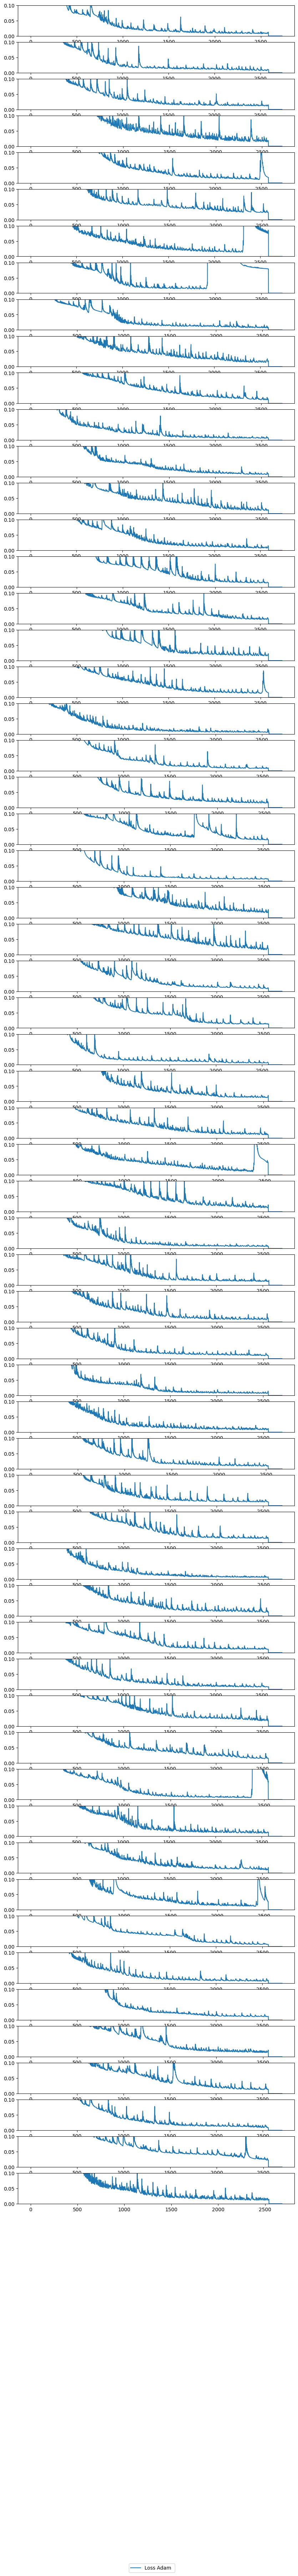

In [ ]:
fig, axes = plt.subplots(nrows=n_models, ncols=len(initial_lambdas), figsize=(10,80))

# fig, axes = plt.subplots(nrows=n_models, ncols=len(initial_lambdas), figsize=(15,5))

for i in range(n_models):
  axes[i].plot(np.linspace(0, len(hists_Adam1[i][0].transpose()),len(hists_Adam1[i][0].transpose())), hists_Adam1[i][0].transpose())
  axes[i].set_ylim([0,1e-1])
  # axes[0].plot(np.linspace(0, len(hists_Adam1[i][0].transpose()),len(hists_Adam1[i][0].transpose())), hists_Adam1[i][0].transpose())
  # axes[0].set_ylim([0,5])

  # axes[1].plot(np.linspace(0, len(hists_Adam1[i][1].transpose()), len(hists_Adam1[i][1].transpose())), hists_Adam1[i][1].transpose())
  # axes[1].set_ylim([0,5])

  # axes[2].plot(np.linspace(0, len(hists_Adam1[i][2].transpose()), len(hists_Adam1[i][2].transpose())), hists_Adam1[i][2].transpose())
  # axes[2].set_ylim([0,5])


  print(f"len Atempt-{i} and init lambda {initial_lambdas[0]}: ",len(hists_Adam1[i][0].transpose()))
  # print(f"len Atempt-{i} and init lambda {initial_lambdas[1]}: ",len(hists_Adam1[i][1].transpose()))
  # print(f"len Atempt-{i} and init lambda {initial_lambdas[2]}: ",len(hists_Adam1[i][2].transpose()))
  # print(f"len Atempt-{i} and init lambda {initial_lambdas[3]}: ",len(hists_Adam1[i][3].transpose()))

# timeout = 250
cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']
rows = ['Attempt {}'.format(row) for row in range(1, n_models+1)]

# pad = 5 # in points


# for ax, col in zip(axes[0], cols):
#   ax.annotate(col, xy=(0.5, 1.05), xytext=(0, pad),
#               xycoords='axes fraction', textcoords='offset points',
#               size='large', ha='center', va='baseline')

# for ax, row in zip(axes[:,0], rows):
#   ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - pad, 0),
#               xycoords=ax.yaxis.label, textcoords='offset points',
#               size='large', ha='right', va='center')

# fig.tight_layout()

fig.legend(['Loss Adam '], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True)

plt.show()

### Predict and Evaluate Inverse Problem

In [ ]:
def lambdas(hists, iter_model, iter_init):
  return lambd_Adam1[i][0].transpose().iloc[-1,:].values[0]

df = pd.DataFrame(columns=['Adam'])
df = df.round(10)

for i in range(n_models):
  x = []
  for j in range(len(initial_lambdas)):
    x.append(lambdas(hists_Adam1, i, j))

  df.loc['Attempt '+str(i+1)] = x

print("Lambda Prediction Given U(x,t)")
df

Lambda Prediction Given U(x,t)


,Adam
Attempt 1,0.486438
Attempt 2,0.470476
Attempt 3,0.478677
Attempt 4,0.479671
Attempt 5,0.491775
Attempt 6,0.480441
Attempt 7,0.463589
Attempt 8,0.465608
Attempt 9,0.470758
Attempt 10,0.467057


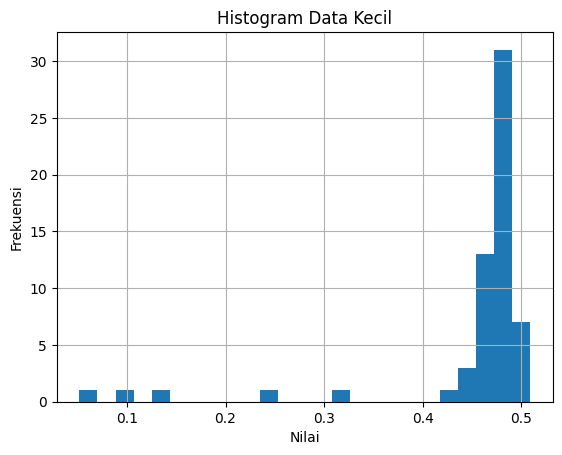

In [ ]:
# bins = np.linspace(0, 0.00009, 11)  # 20 bins antara 0 dan 0.0001
ax = df.iloc[:, 0].plot(kind='hist', bins=25, align='mid')

# plt.xticks(np.linspace(0, 0.00009, 11))  # Misal xtick tiap 0.00001
plt.xlabel("Nilai")
plt.ylabel("Frekuensi")
plt.title("Histogram Data Kecil")
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/scipy/stats/_continuous_distns.py:796: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_continuous_distns.py:801: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))


gengamma     KS=0.2629, p=0.0003787, params=(np.float64(0.022876149058846156), np.float64(2064953885.8734694), np.float64(-2687964.3124353616), np.float64(2687964.8213288235))
fisk         KS=0.2673, p=0.0002831, params=(np.float64(953919489.8332174), np.float64(-27581158.5942048), np.float64(27581159.065977797))
beta         KS=0.2680, p=0.0002696, params=(np.float64(72.07523850194337), np.float64(0.942731546769907), np.float64(-4.097135030554755), np.float64(4.6064387195577465))
burr         KS=0.2743, p=0.0001759, params=(np.float64(1660285560.1220422), np.float64(0.027611813115047172), np.float64(-2250396.0574519485), np.float64(2250396.557655356))
norm         KS=0.3786, p=3.084e-08, params=(np.float64(0.4512864226475358), np.float64(0.09125589032379726))
lognorm      KS=0.3786, p=3.084e-08, params=(np.float64(3.675900460776476e-06), -24825.15262282412, np.float64(24825.603909079047))
invgauss     KS=0.3833, p=1.943e-08, params=(np.float64(0.004605942418876366), np.float64(-1.1187

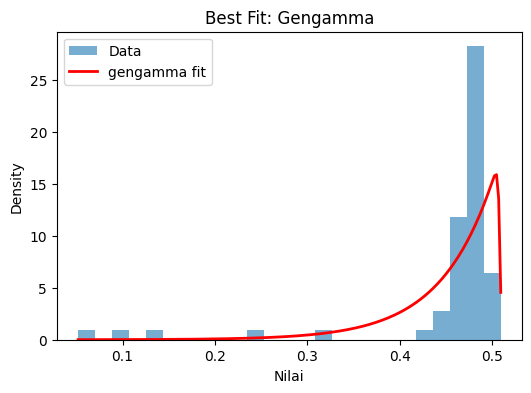

Mean: 0.4512879136018455


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# If df is a DataFrame, pick the column you want to fit:
data = df.iloc[:, 0].to_numpy()  # 1D array

distributions = [
    stats.norm,          # Normal
    stats.expon,         # Exponential
    stats.gamma,         # Gamma
    stats.beta,          # Beta
    stats.lognorm,       # Lognormal
    stats.uniform,       # Uniform
    stats.invgauss,      # Inverse Gaussian
    stats.burr,          # Burr
    stats.fisk,          # Fisk (log-logistic)
    stats.gengamma       # Generalized Gamma
]

results = {}

# Fit tiap distribusi dan uji KS
for dist in distributions:
    try:
        params = dist.fit(data)
        ks_stat, ks_pval = stats.kstest(data, dist.cdf, args=params)
        results[dist.name] = {
            "KS_stat": float(ks_stat),
            "p_value": float(ks_pval),
            "params": params
        }
    except Exception as e:
        results[dist.name] = {"KS_stat": np.inf, "p_value": 0, "params": None}
        print(f"Gagal fit {dist.name}: {e}")

# Urutkan dari KS terkecil
sorted_results = sorted(results.items(), key=lambda x: x[1]["KS_stat"])

# Tampilkan hasil
for name, res in sorted_results:
    if res["params"] is not None:
        print(f"{name:12s} KS={res['KS_stat']:.4f}, p={res['p_value']:.4g}, params={res['params']}")

# Plot best fit
best_name, best_info = sorted_results[0]
best_dist = getattr(stats, best_name)
params = best_info["params"]

x = np.linspace(min(data), max(data), 200)
pdf = best_dist.pdf(x, *params)

plt.figure(figsize=(6,4))
plt.hist(data, bins=25, density=True, alpha=0.6, label="Data")
plt.plot(x, pdf, 'r-', lw=2, label=f"{best_name} fit")
plt.title(f"Best Fit: {best_name.capitalize()}")
plt.xlabel("Nilai")
plt.ylabel("Density")
plt.legend()
plt.show()

params = stats.gengamma.fit(data)
mean = stats.gengamma.mean(*params)
print("Mean:", mean)

In [ ]:
df.describe()

,Adam
count,60.000000
mean,0.451286
std,0.092026
min,0.051768
25%,0.466695
50%,0.477636
75%,0.485886
max,0.509304


In [ ]:
print(df.mean(axis=0).round(10))
df.loc['Average'] = df.mean(axis=0)
df.loc['StdDev'] = df.std(axis=0, ddof=1)
df.loc['CV'] = df.loc['StdDev'] / df.loc['Average']
df.loc[['Average', 'StdDev', 'CV']] = df.loc[['Average', 'StdDev', 'CV']].round(10)
print(df.tail(3))

Adam    0.451286
dtype: float64
             Adam
Average  0.451286
StdDev   0.091256
CV       0.202213


## PDP Model 1 Forward

In [ ]:
n_models = 2

arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':100,'activation':'swish', 'trainable_B':True, 'sigmas':[1.0,2.0], 'mapping_size':64}

models = [None] * n_models

for i in range(n_models):
  tf.random.set_seed(i)
  models[i] = PINN_NeuralNet(lb=lb, ub=ub, **arch)
  models[i].build((None, 3))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [ ]:
lr_comb_param = {'boundaries': [7000,10000,11000,13000,15000,20000],
                 'initial_learning_rate': 1e-2,
                 'decay_steps': 1000,
                 'decay_rate': 0.9,
                 'values_steps': 2}
lr_comb = CombinedDecays(**lr_comb_param)
lr_comb.get_config()

{'initial_learning_rate': 0.01,
 'decay_steps': 1000,
 'decay_rate': 0.9,
 'staircase': False,
 'boundaries': [7000, 10000, 11000, 13000, 15000, 20000],
 'values': [0.004782969000000001,
  0.0023914845000000003,
  0.0011957422500000002,
  0.0005978711250000001,
  0.00029893556250000004,
  0.00014946778125000002,
  7.473389062500001e-05],
 'values_steps': [2, 2, 2, 2, 2, 2],
 'name': None}

Text(0.5, 1, 'Combined Learning Rate')

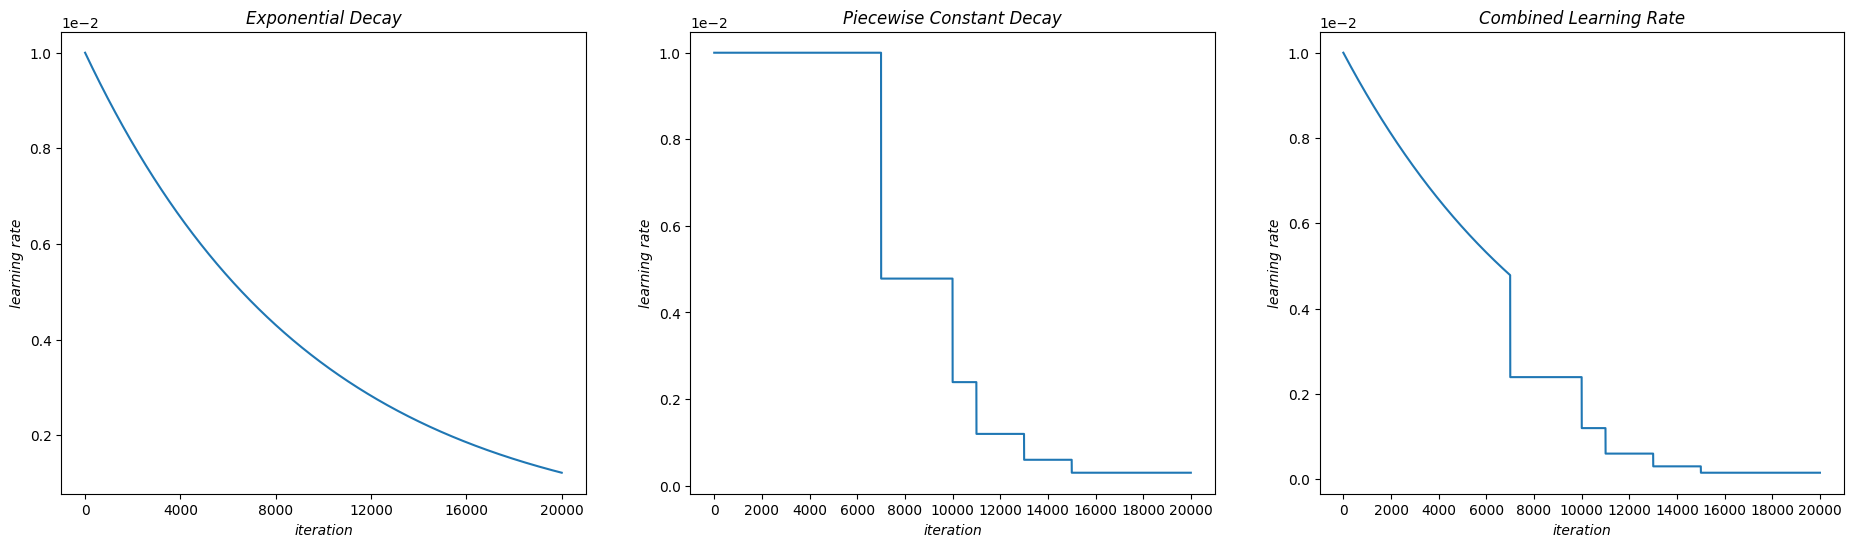

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 20000  # Extended range

fig = plt.figure(figsize=(23, 6))

# ExponentialDecay
initial_learning_rate = lr_comb.initial_learning_rate
decay_steps = lr_comb.decay_steps
decay_rate = lr_comb.decay_rate

learning_rate = []
for i in range(N+1):
    lr = initial_learning_rate * decay_rate ** (i / decay_steps)
    learning_rate.append(lr)

plt.subplot(1, 3, 1)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 4000))
plt.ticklabel_format(axis='y', scilimits=(0, 0))
plt.title('Exponential Decay', y=1, fontstyle='italic')

# Piecewise Constant Decay
boundaries = lr_comb.boundaries
values = lr_comb.values

learning_rate = []
for i in range(N+1):
    for j in range(len(boundaries)):
        if i <= boundaries[0]:
            lr = lr_comb.initial_learning_rate
        elif i <= boundaries[j]:
            lr = values[j-1]
            break
        else:
            lr = values[-1]
    learning_rate.append(lr)

plt.subplot(1, 3, 2)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 2000))
plt.ticklabel_format(axis='y', scilimits=(0, 0))
plt.title('Piecewise Constant Decay', y=1, fontstyle='italic')

# Extended Combined Decay
boundaries = lr_comb.boundaries
values_steps = lr_comb.values_steps  # should be a list like [2, 2, 2, ...]
if isinstance(values_steps, int):
    values_steps = [values_steps] * (len(boundaries))  # Make uniform if scalar

i_stop = boundaries[0]
learning_rate = []

learning_rate = []
i_stop = boundaries[0]

for i in range(N+1):
    if i <= i_stop:
        lr = initial_learning_rate * decay_rate ** (i / decay_steps)
    else:
        for j in range(1, len(boundaries)):
            if boundaries[j-1] < i <= boundaries[j]:
                if i == boundaries[j-1] + 1:
                    # first step into this boundary: decay from previous segment
                    prev_lr = learning_rate[-1]
                    lr = prev_lr / values_steps[j-1]
                else:
                    lr = learning_rate[-1]  # maintain constant
                break
        else:
            # After the last boundary
            lr = learning_rate[-1] / values_steps[-1]
    learning_rate.append(lr)

plt.subplot(1, 3, 3)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 2000))
plt.ticklabel_format(axis='y', scilimits=(0,0))
plt.title('Combined Learning Rate', y=1, fontstyle='italic')



In [13]:
pred_lambda = [0.451286]

In [ ]:
timeout = 1200
start_from = 1


models_Adam_comb = [None]*n_models
hists_Adam_comb = [None]*n_models
batch_size = 4096

for i in range(start_from - 1, n_models):
    models_Adam_comb[i] = []
    hists_Adam_comb[i] = []
    for j, lambd_val in enumerate(pred_lambda):
        print('{:s}\nModel Iteration: {:d}, Lambda Iteration: {:d}\n{:s}'.format(
            50*'-', i+1, j+1, 50*'-'))

        tf.random.set_seed(i + j)  # Use a combined seed for reproducibility

        # Build and initialize model
        models_Adam_comb[i].append(PINN_NeuralNet(lb, ub, **arch))
        models_Adam_comb[i][j].build(input_shape=(None, 3))

        # Set weights and lambda from base model
        models_Adam_comb[i][j].set_weights(models[i].get_weights())
        # Prepare optimizer
        optim_Adam_comb = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay =1e-3)

        # Initialize solver
        solver = PINN_PDESolver(models_Adam_comb[i][j], X_train, fun_r_fwd, get_r_fwd,lambd_val)

        # Train the model
        print('\n\nAdam - Combined Learning Rate\n')
        solver.solve_with_TFoptimizer(optim_Adam_comb, X_train, u_train, W_u, W_v,timeout=timeout,batch_size=batch_size)

        # Store training history
        hists_Adam_comb[i].append(solver.hist)

        print('\n\n\n')

--------------------------------------------------
Model Iteration: 1, Lambda Iteration: 1
--------------------------------------------------


Adam - Combined Learning Rate



/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Streaming output truncated to the last 5000 lines.
PDE Loss: 1.21682638e-06 Data Loss: 0.00866154209 Total Loss: 0.0866166353
PDE Loss: 1.25635199e-06 Data Loss: 0.00860311184 Total Loss: 0.0860323757
PDE Loss: 1.20709365e-06 Data Loss: 0.00845529512 Total Loss: 0.0845541582
PDE Loss: 1.15464127e-06 Data Loss: 0.00741259195 Total Loss: 0.0741270706
PDE Loss: 1.26114196e-06 Data Loss: 0.00742379343 Total Loss: 0.0742391944
PDE Loss: 1.21883727e-06 Data Loss: 0.00794634502 Total Loss: 0.079464674
PDE Loss: 1.30465753e-06 Data Loss: 0.00748783723 Total Loss: 0.0748796761
PDE Loss: 1.23872519e-06 Data Loss: 0.00827933848 Total Loss: 0.0827946216
PDE Loss: 1.28122053e-06 Data Loss: 0.00780932279 Total Loss: 0.0780945122
PDE Loss: 1.46758418e-06 Data Loss: 0.00753926765 Total Loss: 0.0753941461
--- End of Epoch 70, Iteration 70, Average Epoch Loss: 8.568953e-02 ---
PDE Loss: 1.23422399e-06 Data Loss: 0.00858069584 Total Loss: 0.0858081952
PDE Loss: 1.23854011e-06 Data Loss: 0.0086117 Total L

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Streaming output truncated to the last 5000 lines.
PDE Loss: 1.45554509e-06 Data Loss: 0.00665522553 Total Loss: 0.0665537044
PDE Loss: 1.35065159e-06 Data Loss: 0.00610442599 Total Loss: 0.0610456131
PDE Loss: 1.37160293e-06 Data Loss: 0.00626215199 Total Loss: 0.0626228899
PDE Loss: 1.24234145e-06 Data Loss: 0.0056838491 Total Loss: 0.0568397306
PDE Loss: 1.28054637e-06 Data Loss: 0.00601036055 Total Loss: 0.0601048879
PDE Loss: 1.34061236e-06 Data Loss: 0.00601085089 Total Loss: 0.06010985
PDE Loss: 1.15632622e-06 Data Loss: 0.00621524965 Total Loss: 0.0621536523
PDE Loss: 1.31355694e-06 Data Loss: 0.00627742521 Total Loss: 0.0627755672
PDE Loss: 1.3761902e-06 Data Loss: 0.00609453255 Total Loss: 0.0609467
PDE Loss: 1.38022779e-06 Data Loss: 0.00635881256 Total Loss: 0.0635895059
PDE Loss: 1.27490478e-06 Data Loss: 0.00651099626 Total Loss: 0.0651112348
PDE Loss: 1.3362835e-06 Data Loss: 0.00554513186 Total Loss: 0.055452656
PDE Loss: 1.28985175e-06 Data Loss: 0.00674690213 Total Lo

In [14]:
path = dir + "COModel/Fourier/Softplus_Bangkok_Fourier_swish_fwd/"

In [ ]:
for i in range(n_models):
  for j in range(len(pred_lambda)):
    models_Adam_comb[i][j].save_weights(path+"_"+str(i)+"_model_Adam_comb_"+str(j)+".weights.h5", 'h5')


for i in range(n_models):
  for j in range(len(pred_lambda)):
    np.savetxt(path + "loss/_hist_Adam_comb_" + str(i) + "_" + str(j) + ".csv", hists_Adam_comb[i][j], delimiter=",")

In [15]:
n_models = 5

models_Adam_comb = [None] * n_models
arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':100,'activation':'swish', 'trainable_B':True, 'sigmas':[1.0,2.0], 'mapping_size':64}

for i in range(0, n_models):
    models_Adam_comb[i] = []
    for j in range(len(pred_lambda)):
        models_Adam_comb[i].append(PINN_NeuralNet(lb, ub, **arch))
        models_Adam_comb[i][j].build(input_shape=(None, 3))
        _ = models_Adam_comb[i][j](tf.zeros((1, 3)))
        models_Adam_comb[i][j].load_weights(
            path + "_" + str(i) + "_model_Adam_comb_" + str(j) + ".weights.h5"
        )

hists_Adam_comb = [None] * n_models

for i in range(0,n_models):
    hists_Adam_comb[i] = []
    for j in range(len(pred_lambda)):
        hists_Adam_comb[i].append(pd.read_csv(path + "/loss/_hist_Adam_comb_" + str(i) + "_" + str(j) + ".csv",header=None))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_2', however 

### Loss Function

len Atempt-0 Lambda ke- 0:  149
\\
len Atempt-1 Lambda ke- 0:  148
\\
len Atempt-2 Lambda ke- 0:  147
\\
len Atempt-3 Lambda ke- 0:  146
\\
len Atempt-4 Lambda ke- 0:  143
\\


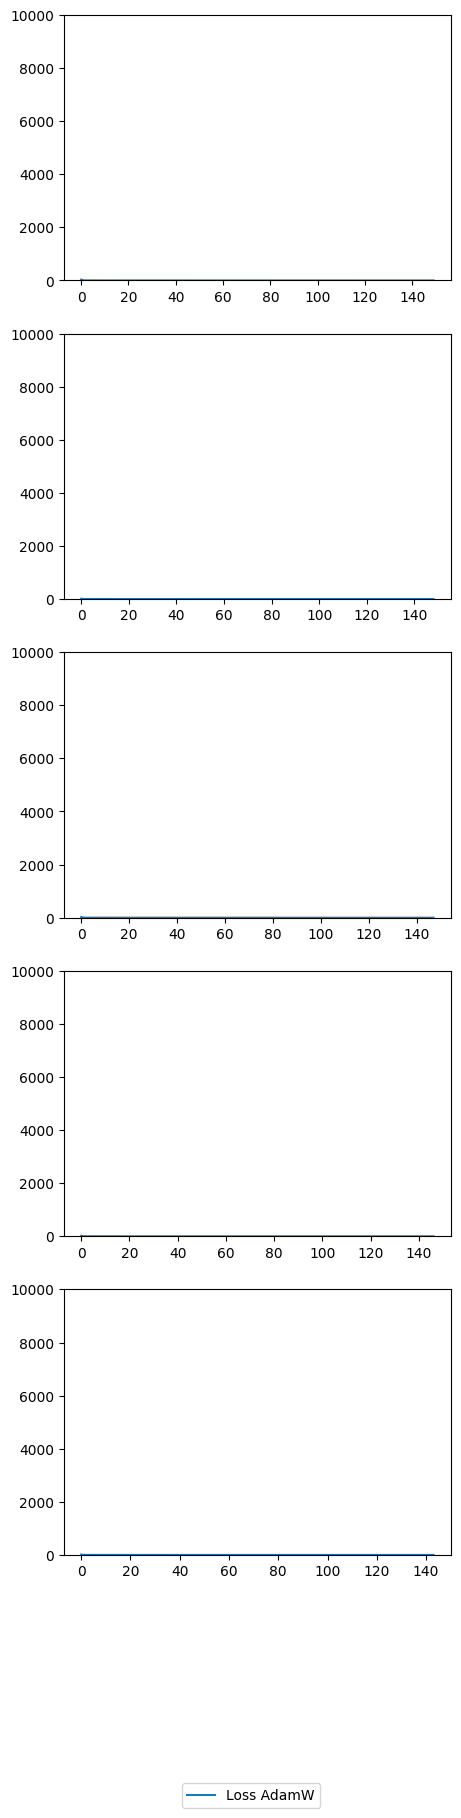

In [ ]:
fig, axes = plt.subplots(nrows=n_models, ncols=len(pred_lambda), figsize=(5,20))

for i in range(n_models):
  for j in range(len(pred_lambda)):
    axes[i].plot(np.linspace(0, len(hists_Adam_comb[i][j]),len(hists_Adam_comb[i][j])), hists_Adam_comb[i][j])
    axes[i].set_ylim([0,1e4])
  # for j in range(len(pred_lambda)):
  #   axes[j].plot(np.linspace(0, len(hists_Adam_comb[i][j]),len(hists_Adam_comb[i][j])), hists_Adam_comb[i][j])
  #   axes[j].set_ylim([0,5e4])


    print(f"len Atempt-{i} Lambda ke- {j}: ",len(hists_Adam_comb[i][j]))
  print("\\\\")

  rows = ['Attempt {}'.format(row) for row in range(1, n_models+1)]

fig.legend(['Loss AdamW'], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True)

plt.show()

### Prediction and Evaluation

In [ ]:
t_unique = np.sort(test_df['time'].unique())
x_unique = np.sort(test_df['x_coord'].unique())
y_unique = np.sort(test_df['y_coord'].unique())


In [ ]:
lb = tf.constant(lb, dtype=tf.float32)
ub = tf.constant(ub, dtype=tf.float32)

In [ ]:
train_Adam_comb = []


t_unique_train = np.sort(train_df['time'].unique())
x_unique_train = np.sort(train_df['x_coord'].unique())
y_unique_train = np.sort(train_df['y_coord'].unique())


for i in range(n_models):
  for j in range(len(pred_lambda)):
    train_Adam_comb.append(predict_solution(models_Adam_comb[i][j], X_train, t_unique_train, x_unique_train, y_unique_train))


df = pd.DataFrame(columns=['Adam'])
initial_lambdas = pred_lambda

# Evaluate and populate the DataFrame
for i in range(n_models):
    results = []
    for j in range(len(initial_lambdas)):
        # Evaluate solutions
        # eval_sgd = pinn.evaluate_solution(preds_SGD[i * len(initial_lambdas) + j], u_star)
        pred_t0 = train_Adam_comb[i * len(initial_lambdas) + j]
        eval_adam = evaluate_solution(pred_t0.numpy(), u_train.numpy())

        # Append results for each lambda
        # results.append(eval_sgd)
        results.append(eval_adam)

    # Add results to DataFrame
    df.loc[f'Attempt {i+1}'] = results

# Display the DataFrame
df


,Adam
Attempt 1,"(0.05163447, 1.3655818)"
Attempt 2,"(0.04568854, 1.1849763)"
Attempt 3,"(0.05493892, 1.436398)"
Attempt 4,"(0.050742224, 1.315268)"
Attempt 5,"(0.04848428, 1.2875007)"


In [ ]:
t_unique = np.sort(test_df['time'].unique())
x_unique = np.sort(test_df['x_coord'].unique())
y_unique = np.sort(test_df['y_coord'].unique())

preds_Adam_comb = []

for i in range(n_models):
  for j in range(len(pred_lambda)):
    preds_Adam_comb.append(predict_solution(models_Adam_comb[i][j], X_test, t_unique, x_unique, y_unique))


In [ ]:
df = pd.DataFrame(columns=['Adam'])
initial_lambdas = pred_lambda

# Evaluate and populate the DataFrame
for i in range(n_models):
    results = []
    for j in range(len(initial_lambdas)):
        # Evaluate solutions
        # eval_sgd = pinn.evaluate_solution(preds_SGD[i * len(initial_lambdas) + j], u_star)
        pred_t0 = preds_Adam_comb[i * len(initial_lambdas) + j]
        eval_adam = evaluate_solution(pred_t0.numpy(), u_test.numpy())

        # Append results for each lambda
        # results.append(eval_sgd)
        results.append(eval_adam)

    # Add results to DataFrame
    df.loc[f'Attempt {i+1}'] = results

# Display the DataFrame
df


,Adam
Attempt 1,"(0.052310497, 1.3834755)"
Attempt 2,"(0.04641346, 1.2041929)"
Attempt 3,"(0.05568429, 1.4558649)"
Attempt 4,"(0.05161283, 1.3393689)"
Attempt 5,"(0.04947206, 1.3124535)"


In [ ]:
def summarise_attempts(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return a tidy table with mean, sample‑SD and CV
    for both numbers contained in each tuple cell.
    """
    summaries = {}
    for col in df.columns:
        arr = np.vstack(df[col].to_numpy())     # shape = (n_attempts, 2)
        μ  = arr.mean(axis=0)                   # mean
        σ  = arr.std(axis=0, ddof=1)            # sample SD (ddof=1)
        cv = σ / μ                              # coefficient of variation
        summaries[col] = {
            "mean_MAE": μ[0], "sd_MAE": σ[0], "cv_MAE": cv[0],
            "mean_MAPE": μ[1], "sd_MAPE": σ[1], "cv_MAPE": cv[1],
        }
    return pd.DataFrame(summaries).T

stats_df = summarise_attempts(df)
print(stats_df)

      mean_MAE    sd_MAE    cv_MAE  mean_MAPE   sd_MAPE   cv_MAPE
Adam  0.051099  0.003441  0.067337   1.339071  0.092889  0.069368


In [ ]:
weights = models_Adam_comb[1][0].get_weights()

for i, w in enumerate(weights):
    print(f"Weight {i}: shape = {w.shape}")
    print(w)

Weight 0: shape = (3, 64)
[[ 0.48567554  1.9384301   0.97605926 -0.79376805 -0.3344192  -1.4405086
  -1.2953938  -1.4383941   1.27035    -1.5315305   0.9704778   0.19043997
  -1.4793482   1.3241701  -1.235344   -2.5029366  -1.5065205   1.256733
  -1.149624   -1.5847231  -0.7075041   1.0986434   1.0634757   2.6073701
   0.20598118 -0.8274672   0.11868886 -1.024247   -0.39565045 -2.3561573
  -1.2987413  -0.57030237 -3.0111666  -0.95008695  1.7950746   0.6007193
   0.6238226  -1.7012084  -0.50192255  0.25276145  0.02251169 -1.3172822
  -2.194808   -1.8464049  -1.2280791   1.1070222  -1.3390465  -0.52401197
   0.7330537   0.96147287 -0.42516202  0.75638527 -0.79717606 -1.0036211
   0.06494641 -1.1185896   1.1134638   0.6012926   1.0015768   0.04668064
  -0.01668453  0.93189317  2.4200115   0.44572476]
 [ 1.7453591   1.9149009  -0.7110212  -1.0979823  -0.21406955 -0.00371735
  -2.2255456   1.2201965  -1.6101078   1.2965426  -0.47131956  0.8711404
  -2.310016    0.54201895  1.1034299  -0.648

# Reconstruction and Imputation

In [16]:
df = pd.read_csv("/content/drive/My Drive/TA/Dataset/Localized/CO_Land_Grid_Bangkok.csv")
df['date'] = pd.to_datetime(df['date'])
df=df.rename(columns={"mean":"CO_mean","latitude":"y_coord","longitude":"x_coord"})
df['time'] = (df['date'] - df['date'].min()).dt.days
df_2 = df[df["CO_mean"] > 0]

df.x_coord = df.x_coord*100
df.y_coord = df.y_coord*100

In [17]:
missing_rows = df[(df["CO_mean"].isna()) | (df["CO_mean"] < 0)][["time", "x_coord", "y_coord"]]
print(len(missing_rows))

# --- Convert to numpy for model input ---
X_missing = missing_rows.to_numpy(dtype=np.float32)

# --- Predict using your model ---
y_pred = models_Adam_comb[1][0].predict_on_batch(X_missing).reshape(-1)
y_pred = y_pred*1e-2
df.x_coord = df.x_coord/100
df.y_coord = df.y_coord/100
df_imputation = df.copy()

# --- Fill missing values ---
df_imputation.loc[(df_imputation["CO_mean"].isna()) | (df_imputation["CO_mean"] < 0), "CO_mean"] = y_pred

df_imputation.describe()

195579


,date,CO_mean,x_coord,y_coord,time
count,556260,556260.000000,556260.000000,556260.000000,556260.00000
mean,2024-04-29 12:00:00,0.038589,100.627874,13.768498,364.50000
min,2023-05-01 00:00:00,0.016655,100.339988,13.499866,0.00000
25%,2023-10-30 00:00:00,0.030020,100.480998,13.702608,182.00000
50%,2024-04-29 12:00:00,0.037712,100.622523,13.770892,364.50000
75%,2024-10-29 00:00:00,0.045377,100.764048,13.844992,547.00000
max,2025-04-29 00:00:00,0.077132,100.932461,13.951460,729.00000
std,NaN,0.009723,0.164272,0.098715,210.73284


In [18]:
#FILTERED DATA
df.x_coord = df.x_coord*100
df.y_coord = df.y_coord*100

unique_coords = df[['time','x_coord', 'y_coord']].drop_duplicates()

df.x_coord = df.x_coord/100
df.y_coord = df.y_coord/100

# Merge with the filtered_df to check presence of CO_filtered
merged = unique_coords.merge(filtered_df[['time', 'x_coord', 'y_coord', 'CO_filtered']],
                          on=['time', 'x_coord', 'y_coord'],
                          how='left')

# Select only the rows where CO_filtered is missing
missing_rows = merged[merged['CO_filtered'].isna()].drop(columns='CO_filtered')

# Result: only (time, x_coord, y_coord) with missing CO_filtered
missing_rows

# --- Predict using your model ---
X_missing_filtered = missing_rows[['time', 'x_coord', 'y_coord']].values
y_pred = models_Adam_comb[1][0].predict_on_batch(X_missing_filtered).reshape(-1)

df_filtered_imputation = filtered_df[["time","x_coord","y_coord","CO_filtered"]]
missing_rows['CO_filtered'] = y_pred

# Merge predicted values back into original dataframe
df_filtered_imputation = pd.concat([df_filtered_imputation, missing_rows],axis=0)

df_filtered_imputation.describe()

df_filtered_imputation.to_csv("Imputation_FilteredData_CO_Bangkok_M3_Swish+Softplus.csv")

In [20]:
df_filtered_imputation.x_coord = df_filtered_imputation.x_coord/100
df_filtered_imputation.y_coord = df_filtered_imputation.y_coord/100
df_filtered_imputation.CO_filtered = df_filtered_imputation.CO_filtered*scale

df_filter = filtered_df.copy()
df_filter.x_coord = df_filter.x_coord/100
df_filter.y_coord = df_filter.y_coord/100

df_filter.CO_filtered = df_filter.CO_filtered*scale

df_filtered_imputation = df_filtered_imputation.sort_values(
    by=['time', 'x_coord', 'y_coord']
).reset_index(drop=True)

In [ ]:
import numpy as np
import pandas as pd
import math
import os
from google.colab import files
from concurrent.futures import ThreadPoolExecutor

# --- 1. Load data dan siapkan grid (1e-4 spacing) ---

# Misal Anda sudah memiliki filtered_df
# Jika belum, upload:
# uploaded = files.upload()
# filtered_df = pd.read_csv("filtered_df.csv")

step = 0.5  # Resolusi

t_min, t_max = filtered_df["time"].min(), filtered_df["time"].max()
x_min, x_max = filtered_df["x_coord"].min(), filtered_df["x_coord"].max()
y_min, y_max = filtered_df["y_coord"].min(), filtered_df["y_coord"].max()

t_points = np.arange(t_min, t_max + step, 1, dtype=np.float32)
x_points = np.arange(x_min, x_max + step, step, dtype=np.float32)
y_points = np.arange(y_min, y_max + step, step, dtype=np.float32)


# --- 2. Pilih model dan path hasil ---
target_indices = [(1, 0)]  # sesuaikan
models_to_use  = [models_Adam_comb[i][j] for i, j in target_indices]
model_labels   = [f"m{i}_{j}" for i, j in target_indices]
file_paths     = [f"/content/Softplus_CO_Bangkok_Fourier_M3_swish_prediction_{label}.csv" for label in model_labels]

# --- 3. Buat file output kosong dengan header ---
for path in file_paths:
    if os.path.exists(path):
        os.remove(path)
    with open(path, "w") as f:
        f.write("t,x,y,prediction\n")

# --- 4. Precompute spatial meshgrid (xy pairs) sekali saja ---
xy_pairs = np.stack(np.meshgrid(x_points, y_points, indexing="ij"), -1).reshape(-1, 2)

# --- 5. Fungsi batch generator ---
def gen_batches(t_vec, batch_size=1_000_000):
    for t in t_vec:
        t_col = np.full((xy_pairs.shape[0], 1), t, dtype=np.float32)
        tx_y = np.hstack([t_col, xy_pairs])
        n_rows = tx_y.shape[0]
        n_batch = math.ceil(n_rows / batch_size)
        for k in range(n_batch):
            yield t, tx_y[k * batch_size : (k + 1) * batch_size]

# --- 6. Fungsi prediksi + tulis ke file ---
def predict_and_write(model, batch, path):
    pred = model.predict_on_batch(batch).reshape(-1, 1)
    output = np.hstack([batch, pred])
    df = pd.DataFrame(output, columns=["t", "x", "y", "prediction"])
    df.to_csv(path, mode="a", header=False, index=False, float_format="%.6g")

# --- 7. Loop utama: batch per waktu + paralel tulis model ---
for t_val, batch in gen_batches(t_points):
    print(f"Processing time: {t_val}, Batch shape: {batch.shape}")
    with ThreadPoolExecutor() as executor:
        for model, path in zip(models_to_use, file_paths):
            executor.submit(predict_and_write, model, batch, path)

Processing time: 0.0, Batch shape: (11040, 3)
Processing time: 1.0, Batch shape: (11040, 3)
Processing time: 2.0, Batch shape: (11040, 3)
Processing time: 3.0, Batch shape: (11040, 3)
Processing time: 4.0, Batch shape: (11040, 3)
Processing time: 5.0, Batch shape: (11040, 3)
Processing time: 6.0, Batch shape: (11040, 3)
Processing time: 7.0, Batch shape: (11040, 3)
Processing time: 8.0, Batch shape: (11040, 3)
Processing time: 9.0, Batch shape: (11040, 3)
Processing time: 10.0, Batch shape: (11040, 3)
Processing time: 11.0, Batch shape: (11040, 3)
Processing time: 12.0, Batch shape: (11040, 3)
Processing time: 13.0, Batch shape: (11040, 3)
Processing time: 14.0, Batch shape: (11040, 3)
Processing time: 15.0, Batch shape: (11040, 3)
Processing time: 16.0, Batch shape: (11040, 3)
Processing time: 17.0, Batch shape: (11040, 3)
Processing time: 18.0, Batch shape: (11040, 3)
Processing time: 19.0, Batch shape: (11040, 3)
Processing time: 20.0, Batch shape: (11040, 3)
Processing time: 21.0, 

In [ ]:
prediction_df =pd.read_csv("/content/Softplus_CO_Bangkok_Fourier_M3_swish_prediction_m1_0.csv")
prediction_cleaned_df =prediction_df.copy()
prediction_cleaned_df['prediction'] = prediction_df['prediction'].apply(lambda x: 0 if x < 0 else x)

prediction_df.prediction = prediction_df.prediction*1e-2
prediction_df.x = prediction_df.x/100
prediction_df.y = prediction_df.y/100

In [ ]:
prediction_df.describe()

,t,x,y,prediction
count,8.059200e+06,8.059200e+06,8.059200e+06,8.059200e+06
mean,3.645000e+02,1.006375e+02,1.372840e+01,3.830637e-02
std,2.107327e+02,1.731991e-01,1.327827e-01,9.262923e-03
min,0.000000e+00,1.003400e+02,1.350090e+01,9.805750e-07
25%,1.820000e+02,1.004887e+02,1.361465e+01,3.019390e-02
50%,3.645000e+02,1.006375e+02,1.372840e+01,3.760070e-02
75%,5.470000e+02,1.007862e+02,1.384215e+01,4.512590e-02
max,7.290000e+02,1.009350e+02,1.395590e+01,6.862110e-02


In [ ]:
len(prediction_df[prediction_df.prediction<0])

0

# 2024 Thailand school bus Fire October 1st


t = 517


/tmp/ipython-input-2544747560.py:54: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-2544747560.py:54: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-2544747560.py:54: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-inp

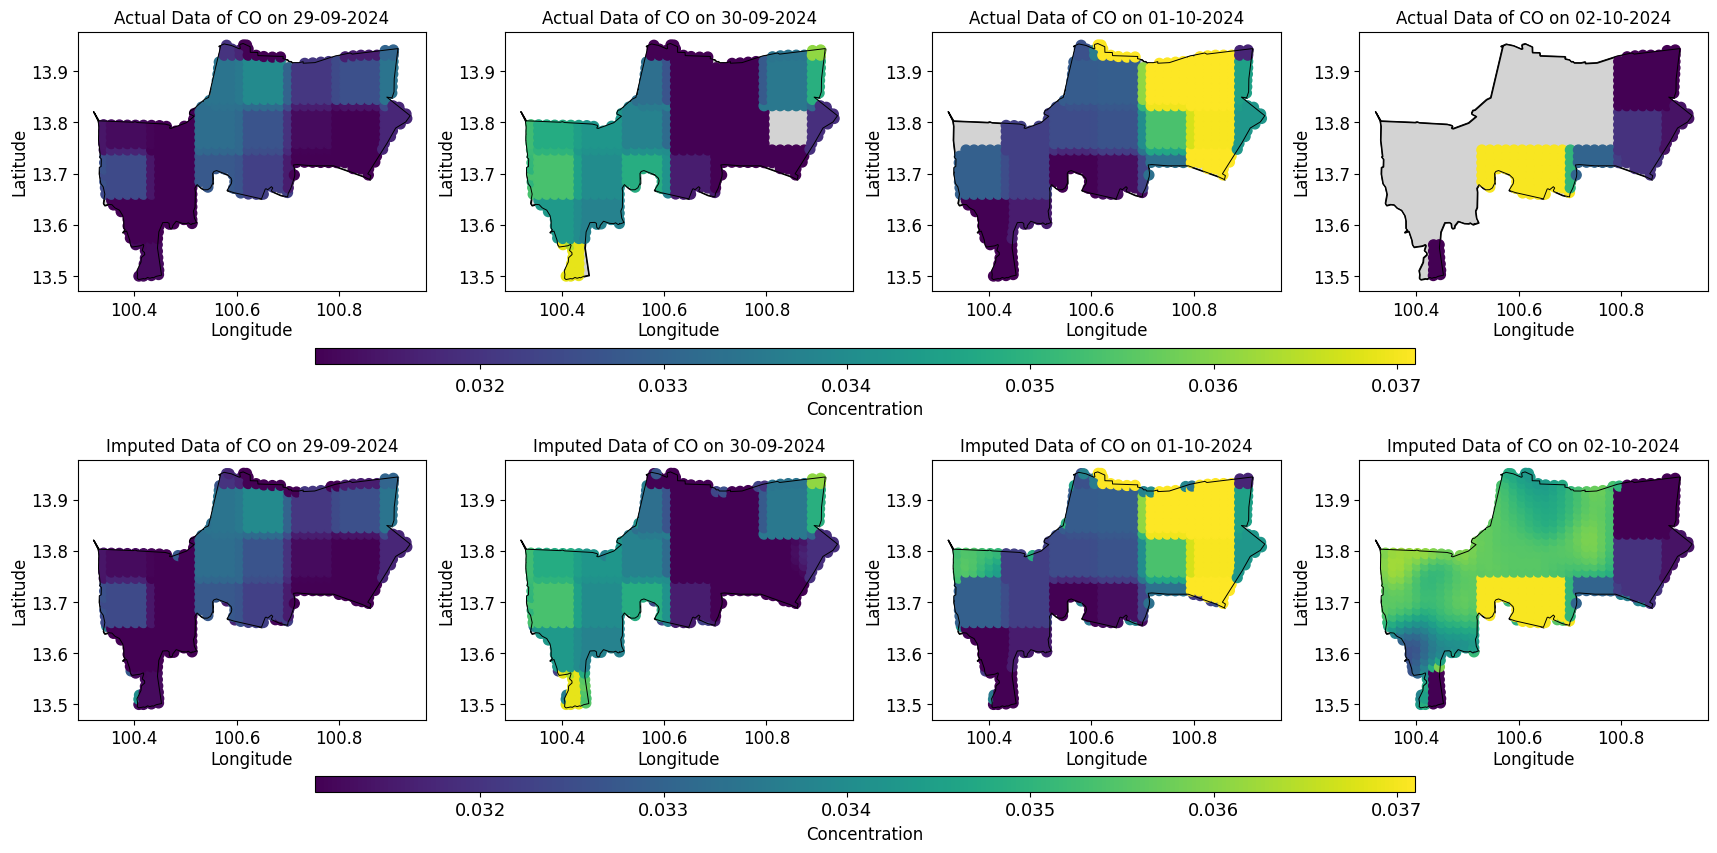

In [ ]:
# @title
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import matplotlib as mpl
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap

viridis = plt.cm.viridis(np.linspace(0, 1, 256))
# Define a smooth gradient from yellow to orange to red (HSV-based blending)
yellow_to_red = np.array([
    [253/255, 231/255, 37/255, 1],  # #FDE725
    [1.0, 0.65, 0.0, 1.0],  # orange
    [1.0, 0.0, 0.0, 1.0]    # red
])
n_extend = int(256 * 0.25)

colors = np.vstack((
    viridis,
    np.linspace(yellow_to_red[0], yellow_to_red[-1], n_extend)
))

# Create the final colormap
viridis_to_red = LinearSegmentedColormap.from_list(
    "viridis_yellow_orange_red", colors
)



# --- Step 1: Define the start date ---
start_date = datetime(2023, 5, 1)  # Fixed starting date

# --- Step 2: Input your target date ---
target_day = 29
target_month = 9
target_year = 2024
target_date = datetime(target_year, target_month, target_day)

t = (target_date - start_date).days
print("t =", t)

# --- Step 3: Load Bangkok shapefile ---
# thailand = gpd.read_file(
#     'https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_THA_1.json'
# )
# bangkok = thailand[thailand['NAME_1'] == 'BangkokMetropolis']
# bangkok['centroid'] = bangkok.geometry.centroid


# --- Step 4: Define the offsets you want to compare ---
day_offsets = [0,1,2,3]

# --- Step 5: Setup figure (rows = dates, cols = 2 for df & df_imputation) ---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(5.5 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}
vmin, vmax = 0.0311, 0.0371

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Actual Data"), (df_imputation, "Imputed Data")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")

        bangkok.plot(ax=ax, color='lightgray', edgecolor='black')
        bangkok.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                cmap='viridis',
                vmin=vmin, vmax=vmax, markersize=50
            )
            mappables[label] = mappable

        ax.set_title(f"{label} of CO on {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Longitude", fontsize=12, labelpad=2)
        ax.set_ylabel("Latitude", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Concentration", fontsize=12)
cbar1.ax.tick_params(labelsize=13,pad=6)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Concentration", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


t = 517


/tmp/ipython-input-3942509172.py:47: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bangkok['centroid'] = bangkok.geometry.centroid
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/tmp/ipython-input-3942509172.py:76: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/i

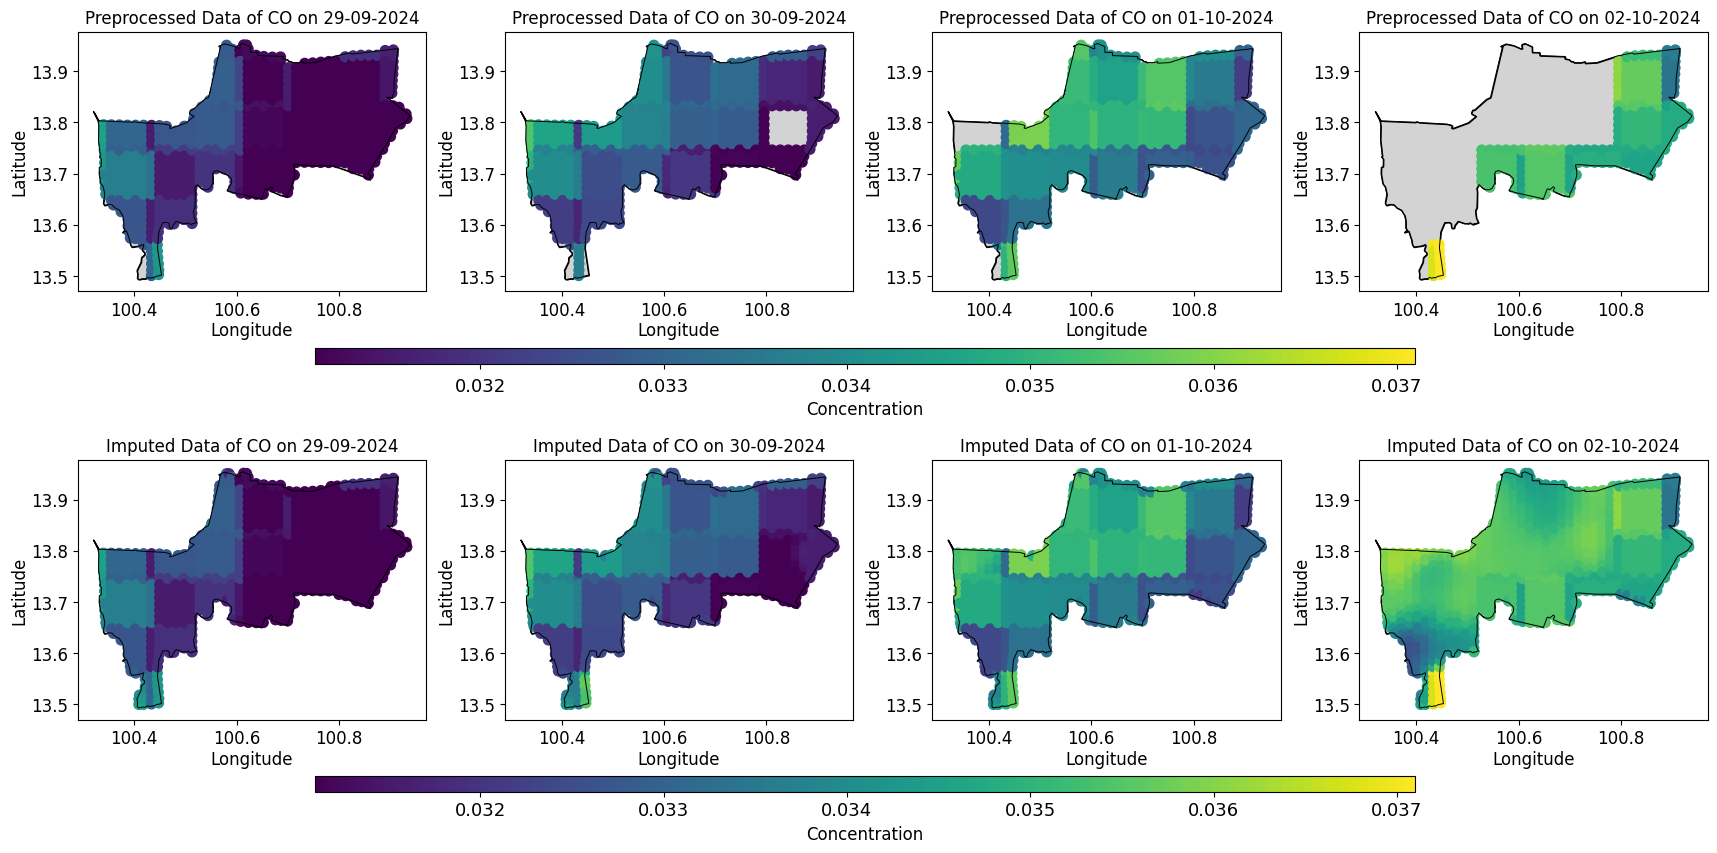

In [21]:
# @title
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import matplotlib as mpl
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap

viridis = plt.cm.viridis(np.linspace(0, 1, 256))
# Define a smooth gradient from yellow to orange to red (HSV-based blending)
yellow_to_red = np.array([
    [253/255, 231/255, 37/255, 1],  # #FDE725
    [1.0, 0.65, 0.0, 1.0],  # orange
    [1.0, 0.0, 0.0, 1.0]    # red
])
n_extend = int(256 * 0.25)

colors = np.vstack((
    viridis,
    np.linspace(yellow_to_red[0], yellow_to_red[-1], n_extend)
))

# Create the final colormap
viridis_to_red = LinearSegmentedColormap.from_list(
    "viridis_yellow_orange_red", colors
)



# --- Step 1: Define the start date ---
start_date = datetime(2023, 5, 1)  # Fixed starting date

# --- Step 2: Input your target date ---
target_day = 29
target_month = 9
target_year = 2024
target_date = datetime(target_year, target_month, target_day)

t = (target_date - start_date).days
print("t =", t)

# --- Step 3: Load Bangkok shapefile ---
thailand = gpd.read_file(
    'https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_THA_1.json'
)
bangkok = thailand[thailand['NAME_1'] == 'BangkokMetropolis']
bangkok['centroid'] = bangkok.geometry.centroid


# --- Step 4: Define the offsets you want to compare ---
day_offsets = [0,1,2,3]

# --- Step 5: Setup figure (rows = dates, cols = 2 for df & df_imputation) ---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(5.5 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}
vmin, vmax = 0.0311, 0.0371

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df_filter, "Preprocessed Data"), (df_filtered_imputation, "Imputed Data")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")

        bangkok.plot(ax=ax, color='lightgray', edgecolor='black')
        bangkok.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_filtered', ax=ax,
                cmap='viridis',
                vmin=vmin, vmax=vmax, markersize=50
            )
            mappables[label] = mappable

        ax.set_title(f"{label} of CO on {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Longitude", fontsize=12, labelpad=2)
        ax.set_ylabel("Latitude", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Concentration", fontsize=12)
cbar1.ax.tick_params(labelsize=13,pad=6)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Concentration", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


/tmp/ipython-input-2938172732.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-2938172732.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-2938172732.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-inp

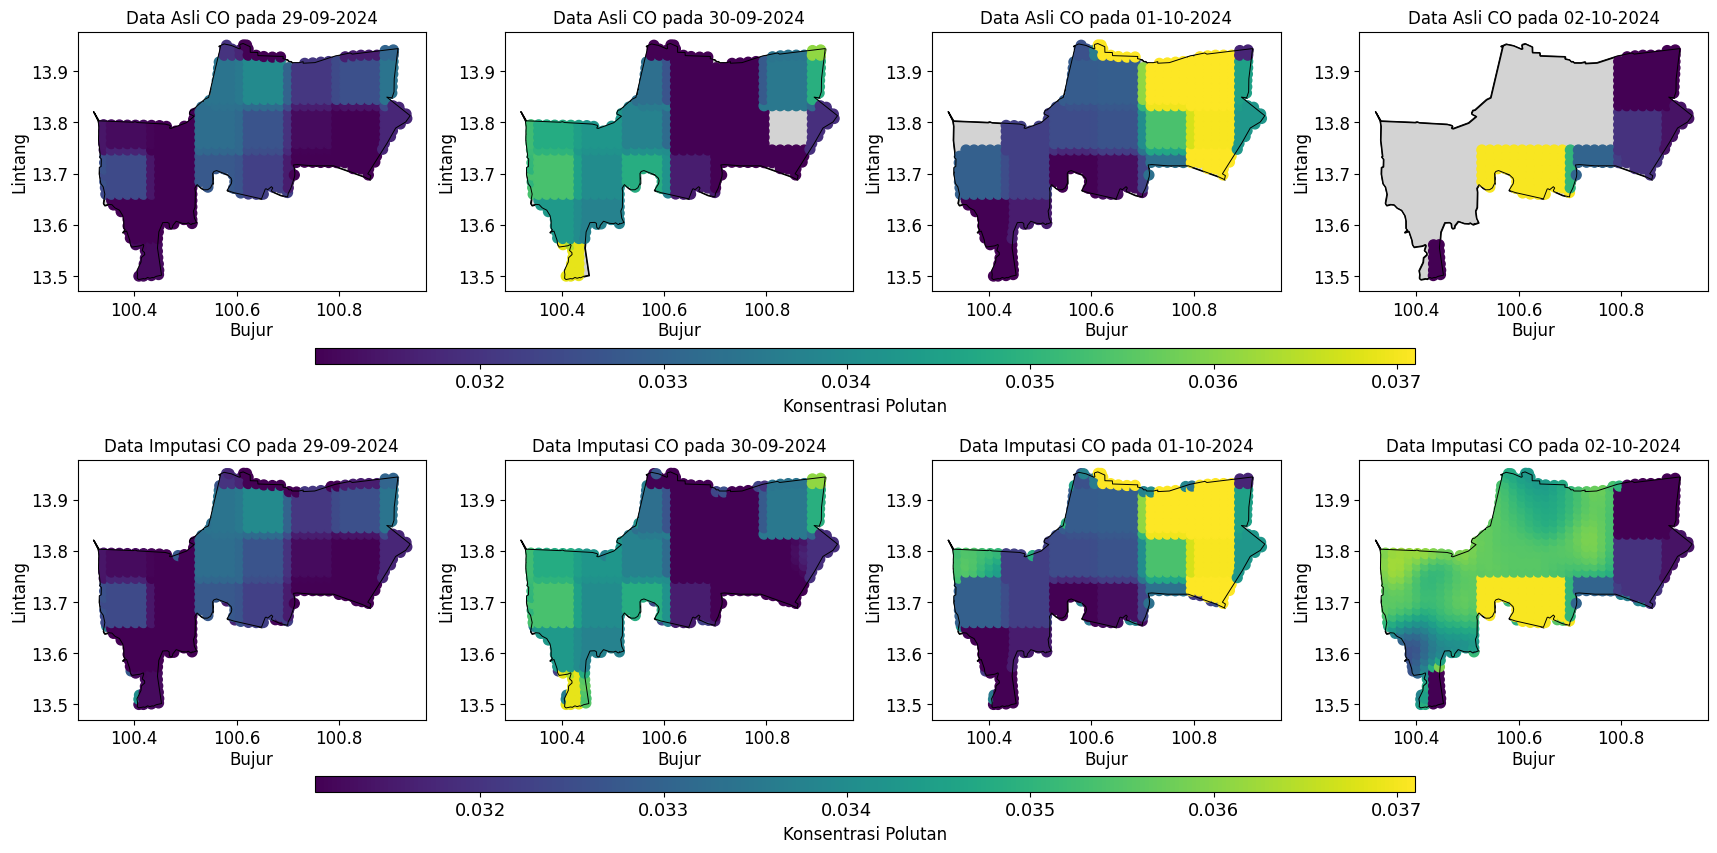

In [ ]:
# @title
# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(5.5 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Data Asli"), (df_imputation, "Data Imputasi")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")

        bangkok.plot(ax=ax, color='lightgray', edgecolor='black')
        bangkok.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
               cmap='viridis',
              vmin=vmin, vmax=vmax, markersize=50

            )
            mappables[label] = mappable


        ax.set_title(f"{label} CO pada {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Bujur", fontsize=12, labelpad=2)
        ax.set_ylabel("Lintang", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Konsentrasi Polutan", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Konsentrasi Polutan", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


/tmp/ipython-input-1833147595.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-1833147595.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-1833147595.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-inp

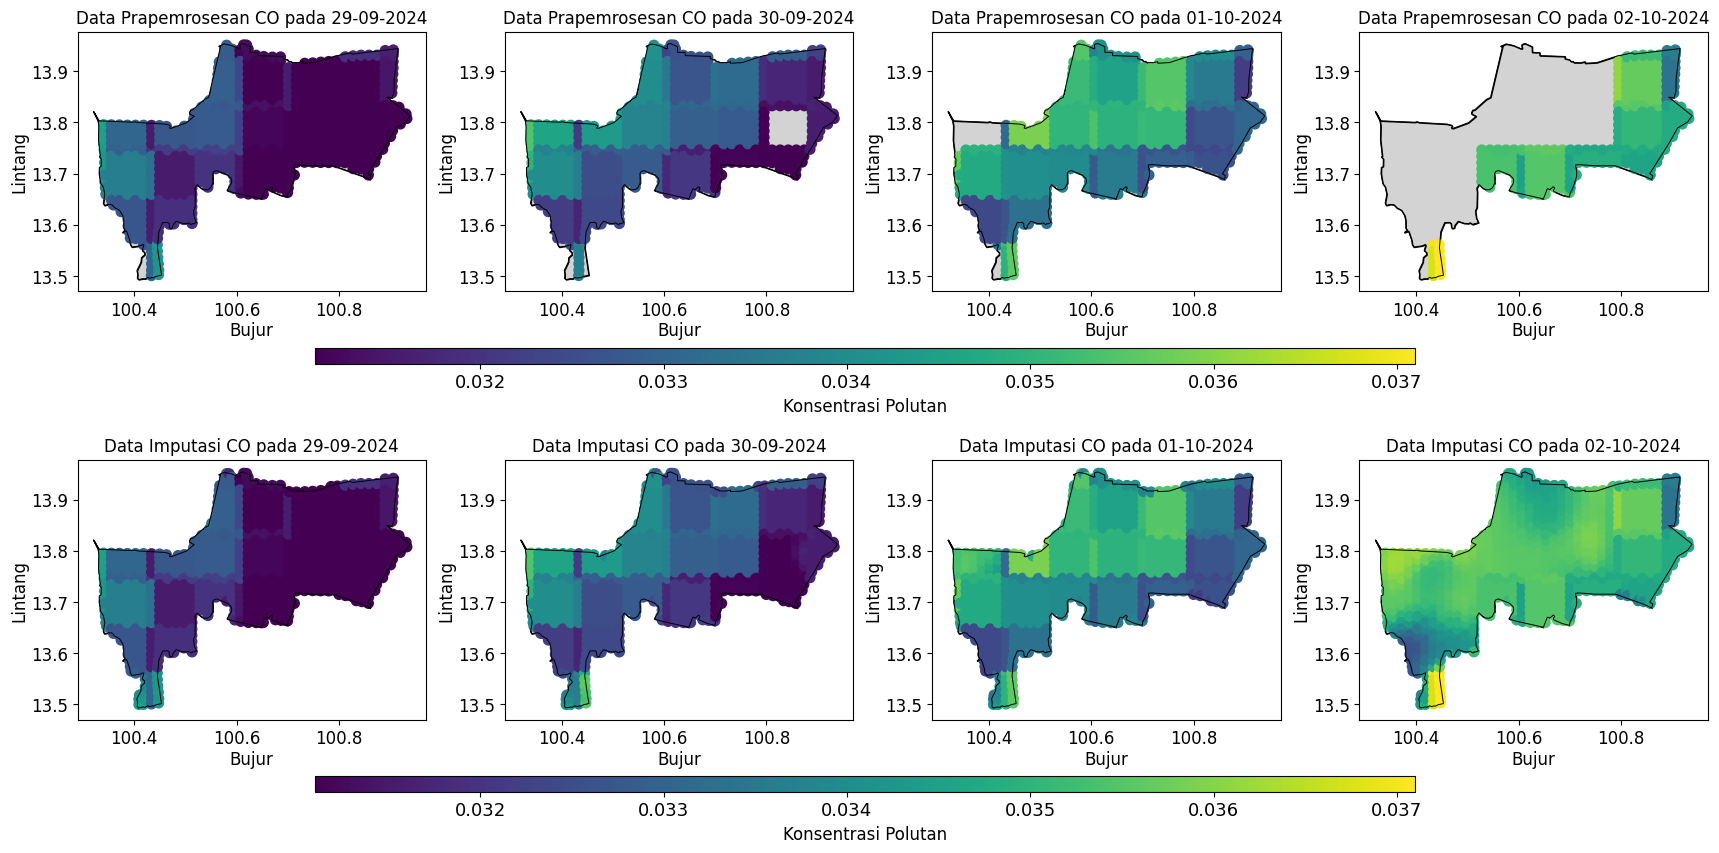

In [23]:
# @title
# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(5.5 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df_filter, "Data Prapemrosesan"), (df_filtered_imputation, "Data Imputasi")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")

        bangkok.plot(ax=ax, color='lightgray', edgecolor='black')
        bangkok.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_filtered', ax=ax,
               cmap='viridis',
              vmin=vmin, vmax=vmax, markersize=50

            )
            mappables[label] = mappable


        ax.set_title(f"{label} CO pada {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Bujur", fontsize=12, labelpad=2)
        ax.set_ylabel("Lintang", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Konsentrasi Polutan", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Konsentrasi Polutan", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


/tmp/ipython-input-3518516449.py:27: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-3518516449.py:27: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-3518516449.py:27: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-inp

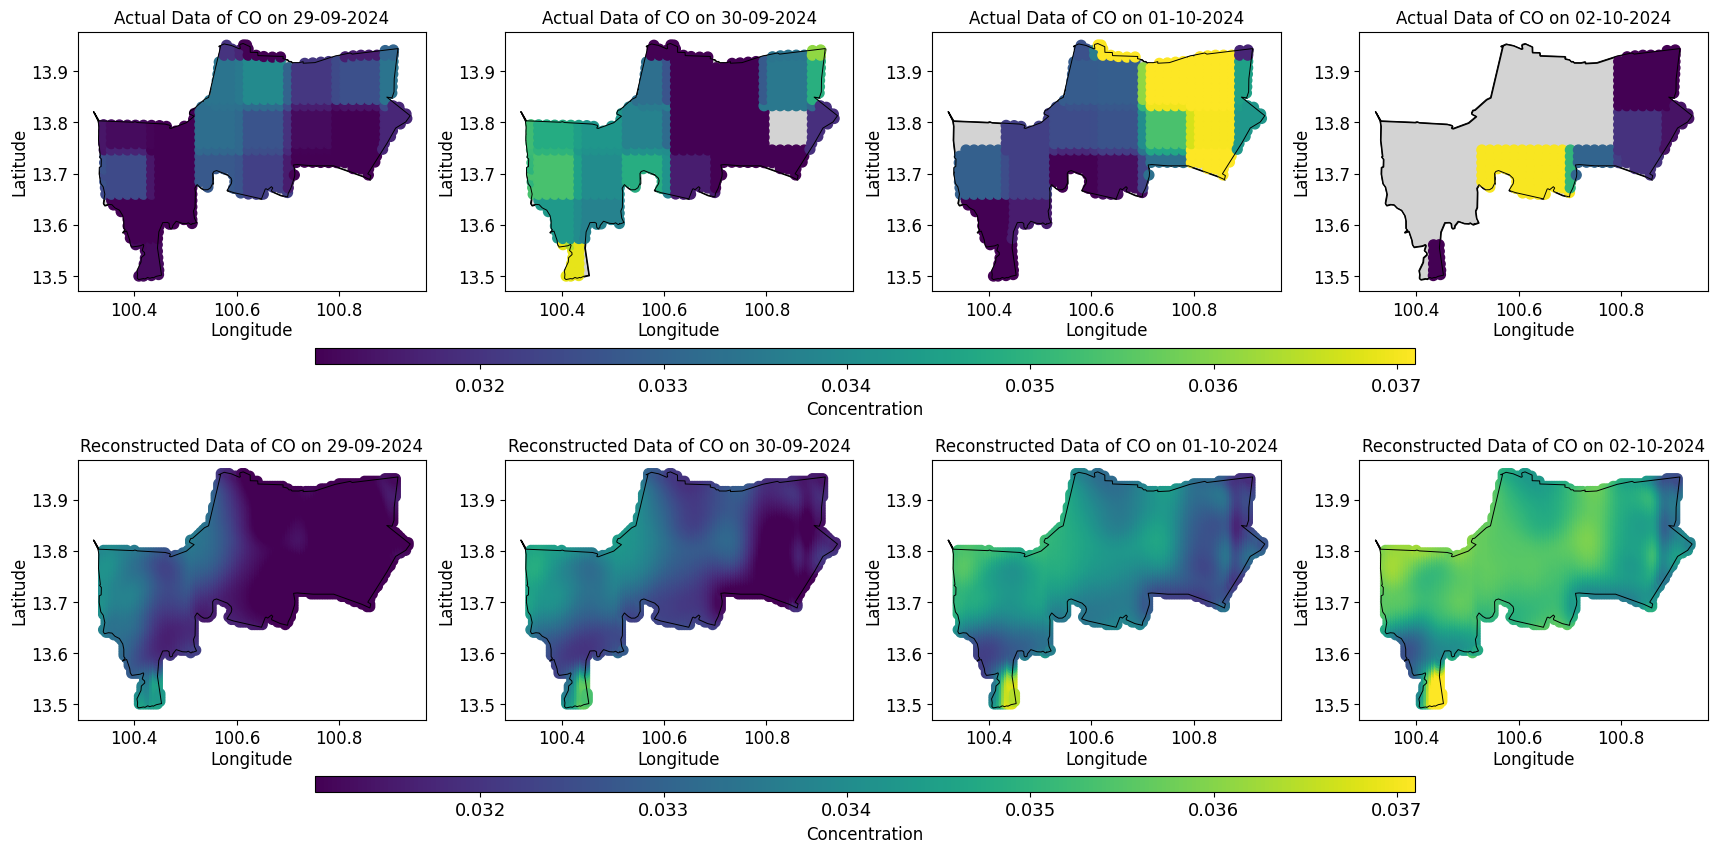

In [ ]:
# @title


predict = prediction_df.copy()
predict = predict.rename(columns={'prediction':'CO_mean','t':'time','x':'x_coord','y':'y_coord'})


# --- Step 5: Setup figure (rows = dates, cols = 2 for df & df_imputation) ---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(5.5 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Actual Data"), (predict, "Reconstructed Data")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")

        bangkok.plot(ax=ax, color='lightgray', edgecolor='black')
        bangkok.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                cmap='viridis',
                vmin=vmin, vmax=vmax, markersize=50
            )
            mappables[label] = mappable

        ax.set_title(f"{label} of CO on {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Longitude", fontsize=12, labelpad=2)
        ax.set_ylabel("Latitude", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Concentration", fontsize=12)
cbar1.ax.tick_params(labelsize=13,pad=6)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Concentration", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


/tmp/ipython-input-1954647060.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-1954647060.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-1954647060.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-inp

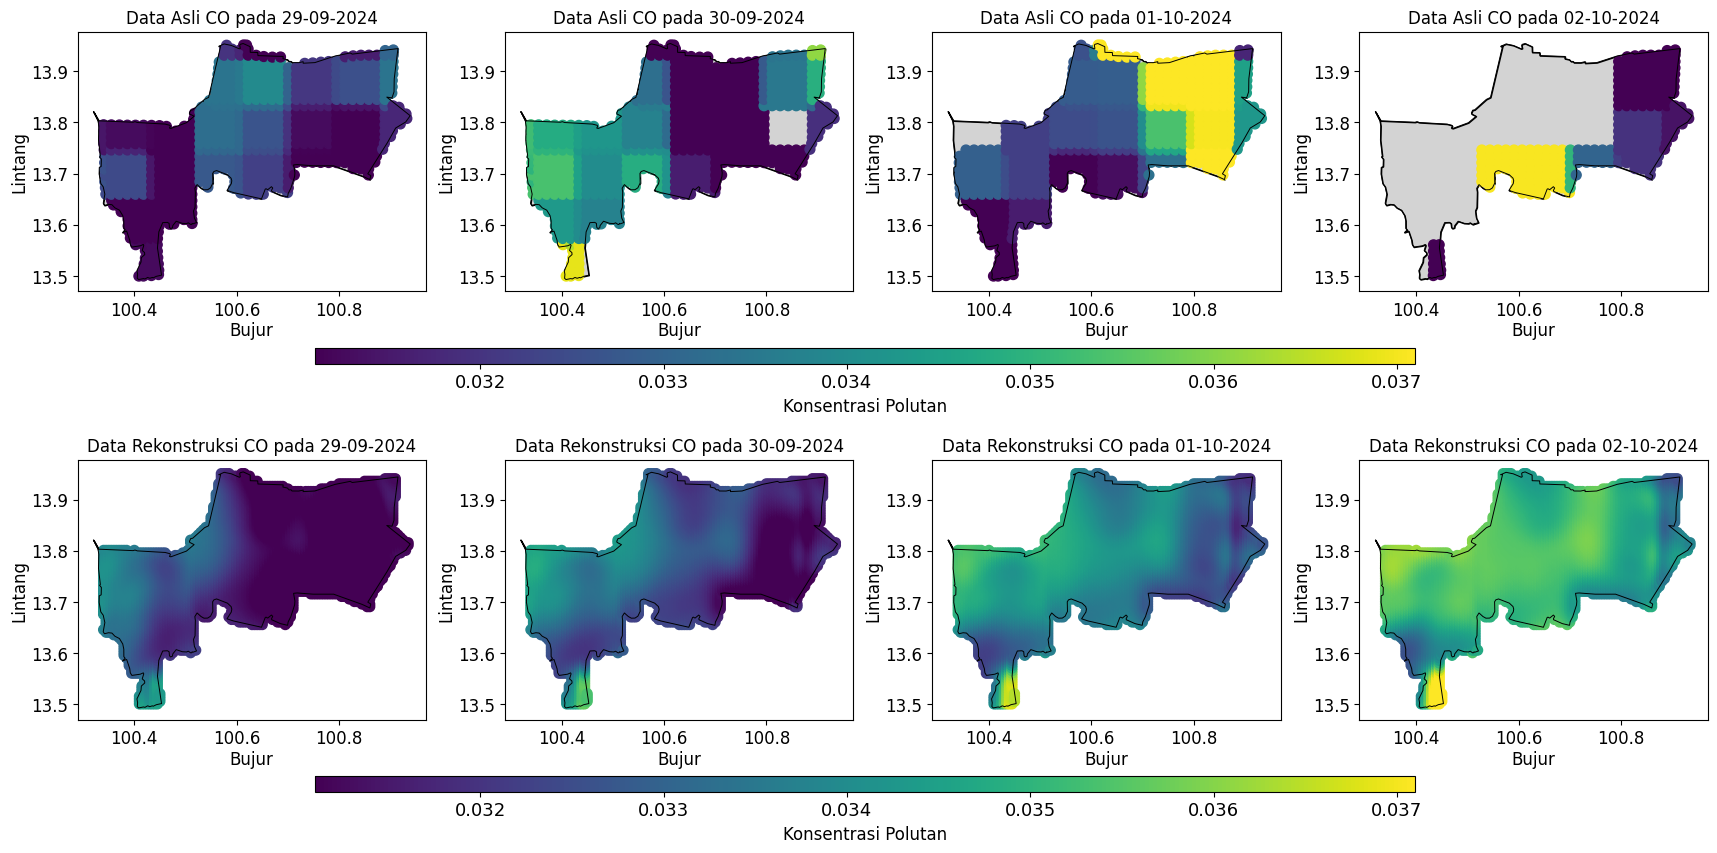

In [ ]:
# @title
# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(5.5 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Data Asli"), (predict, "Data Rekonstruksi")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")

        bangkok.plot(ax=ax, color='lightgray', edgecolor='black')
        bangkok.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                cmap='viridis', vmin=vmin, vmax=vmax, markersize=50
            )
            mappables[label] = mappable


        ax.set_title(f"{label} CO pada {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Bujur", fontsize=12, labelpad=2)
        ax.set_ylabel("Lintang", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Konsentrasi Polutan", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Konsentrasi Polutan", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


# 18 January Fire Wood Factory

t = 625


/tmp/ipython-input-369969577.py:54: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-369969577.py:54: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-369969577.py:54: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-

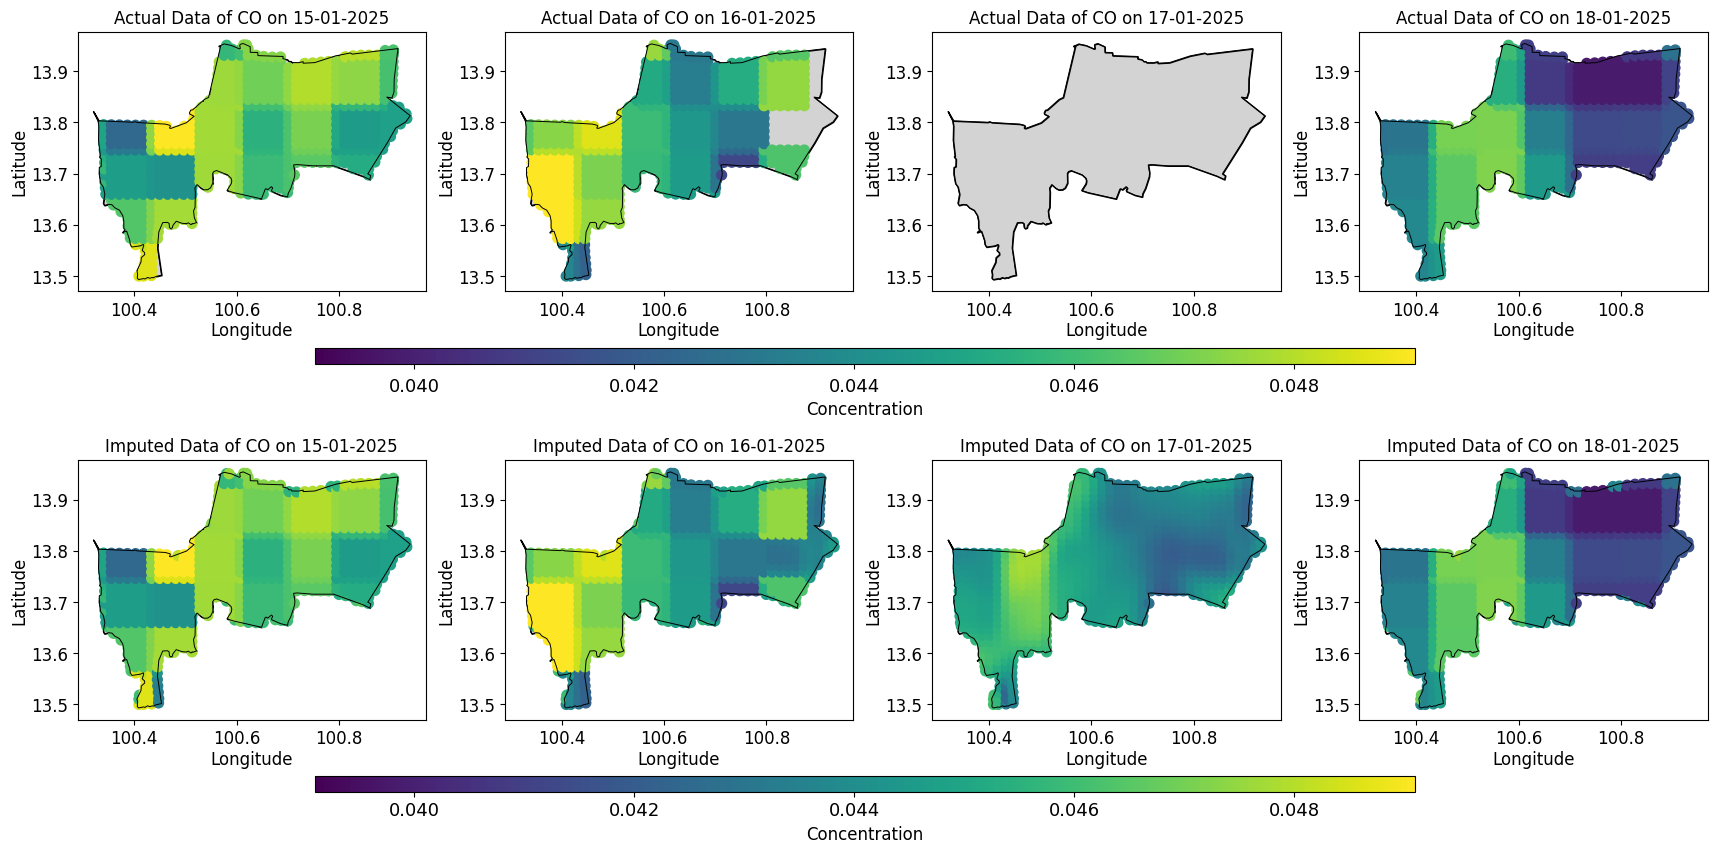

In [ ]:
# @title
# from datetime import datetime, timedelta
# import matplotlib.pyplot as plt
# import geopandas as gpd
# from shapely.geometry import Point
# import matplotlib as mpl
# import matplotlib.patheffects as pe

# --- Step 1: Define the start date ---
start_date = datetime(2023, 5, 1)  # Fixed starting date

# --- Step 2: Input your target date ---
target_day = 15
target_month = 1
target_year = 2025
target_date = datetime(target_year, target_month, target_day)

t = (target_date - start_date).days
print("t =", t)

# --- Step 3: Load Bangkok shapefile ---
# thailand = gpd.read_file(
#     'https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_THA_1.json'
# )
# bangkok = thailand[thailand['NAME_1'] == 'BangkokMetropolis']
# bangkok['centroid'] = bangkok.geometry.centroid


# --- Step 4: Define the offsets you want to compare ---
day_offsets = [0,1,2,3]

# --- Step 5: Setup figure (rows = dates, cols = 2 for df & df_imputation) ---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(5.5 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}
vmin, vmax = 0.0391, 0.0491

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Actual Data"), (df_imputation, "Imputed Data")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")

        bangkok.plot(ax=ax, color='lightgray', edgecolor='black')
        bangkok.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                cmap='viridis',
                vmin=vmin, vmax=vmax, markersize=50
            )
            mappables[label] = mappable

        ax.set_title(f"{label} of CO on {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Longitude", fontsize=12, labelpad=2)
        ax.set_ylabel("Latitude", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Concentration", fontsize=12)
cbar1.ax.tick_params(labelsize=13,pad=6)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Concentration", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


t = 625


/tmp/ipython-input-2834470298.py:54: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-2834470298.py:54: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-2834470298.py:54: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-inp

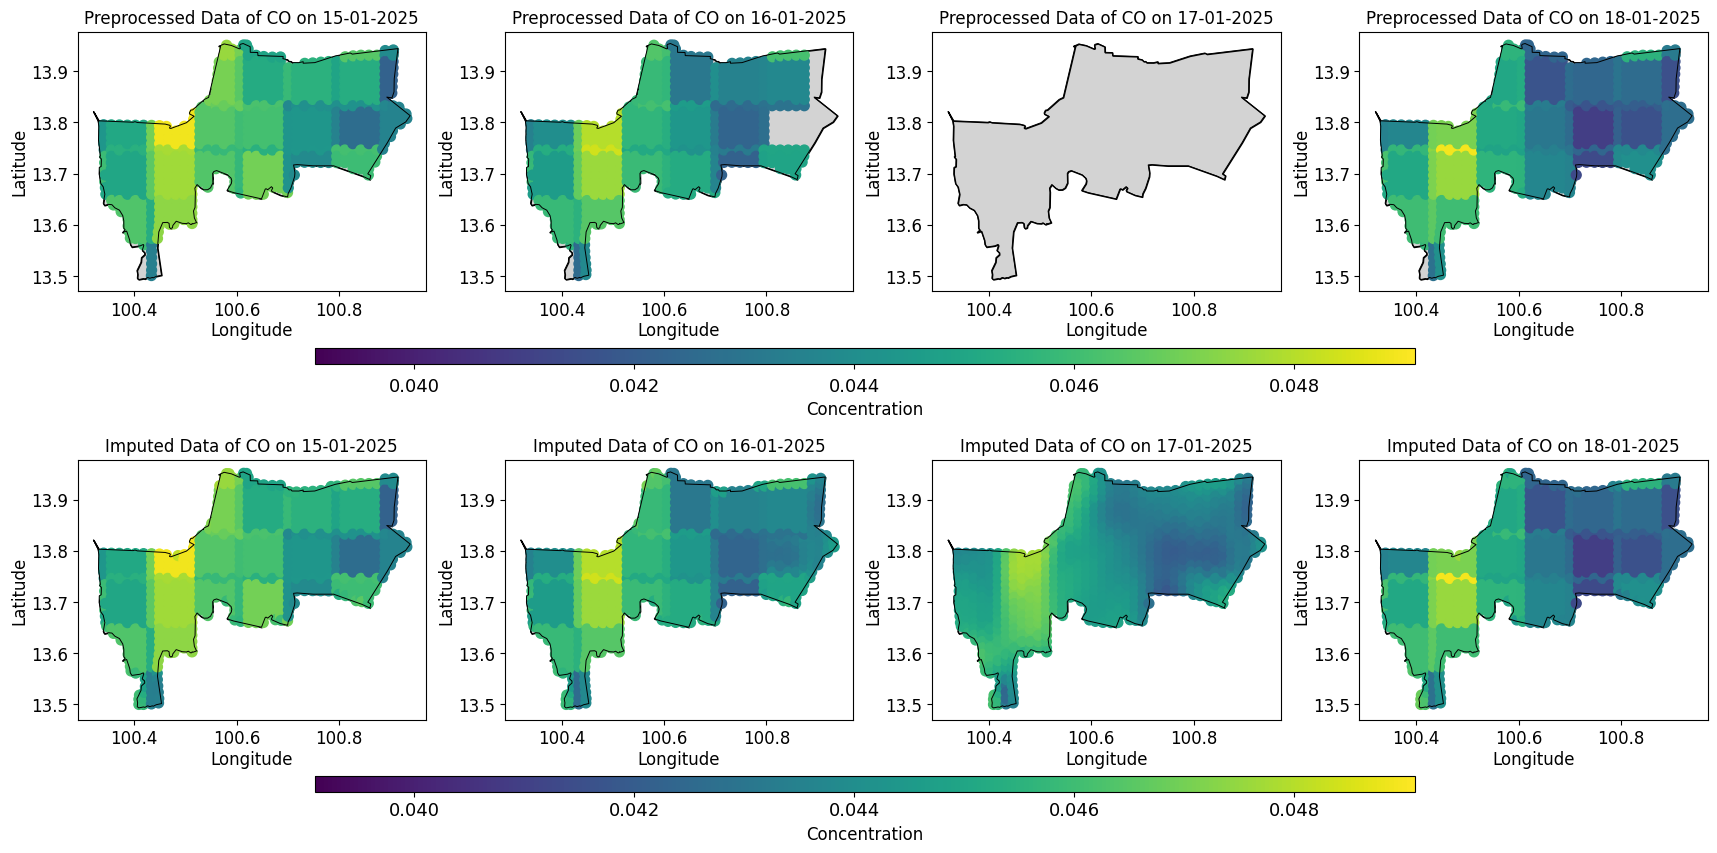

In [30]:
# @title
# from datetime import datetime, timedelta
# import matplotlib.pyplot as plt
# import geopandas as gpd
# from shapely.geometry import Point
# import matplotlib as mpl
# import matplotlib.patheffects as pe

# --- Step 1: Define the start date ---
start_date = datetime(2023, 5, 1)  # Fixed starting date

# --- Step 2: Input your target date ---
target_day = 15
target_month = 1
target_year = 2025
target_date = datetime(target_year, target_month, target_day)

t = (target_date - start_date).days
print("t =", t)

# --- Step 3: Load Bangkok shapefile ---
# thailand = gpd.read_file(
#     'https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_THA_1.json'
# )
# bangkok = thailand[thailand['NAME_1'] == 'BangkokMetropolis']
# bangkok['centroid'] = bangkok.geometry.centroid


# --- Step 4: Define the offsets you want to compare ---
day_offsets = [0,1,2,3]

# --- Step 5: Setup figure (rows = dates, cols = 2 for df & df_imputation) ---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(5.5 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}
vmin, vmax = 0.0391, 0.0491

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df_filter, "Preprocessed Data"), (df_filtered_imputation, "Imputed Data")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
           df_visualize = df[df['time'] == time_to_visualize].copy()
           df_visualize = df_visualize.rename(columns={'CO_mean':'CO_filtered'})

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")

        bangkok.plot(ax=ax, color='lightgray', edgecolor='black')
        bangkok.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_filtered', ax=ax,
                cmap='viridis',
                vmin=vmin, vmax=vmax, markersize=50
            )
            mappables[label] = mappable

        ax.set_title(f"{label} of CO on {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Longitude", fontsize=12, labelpad=2)
        ax.set_ylabel("Latitude", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Concentration", fontsize=12)
cbar1.ax.tick_params(labelsize=13,pad=6)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Concentration", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


/tmp/ipython-input-2938172732.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-2938172732.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-2938172732.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-inp

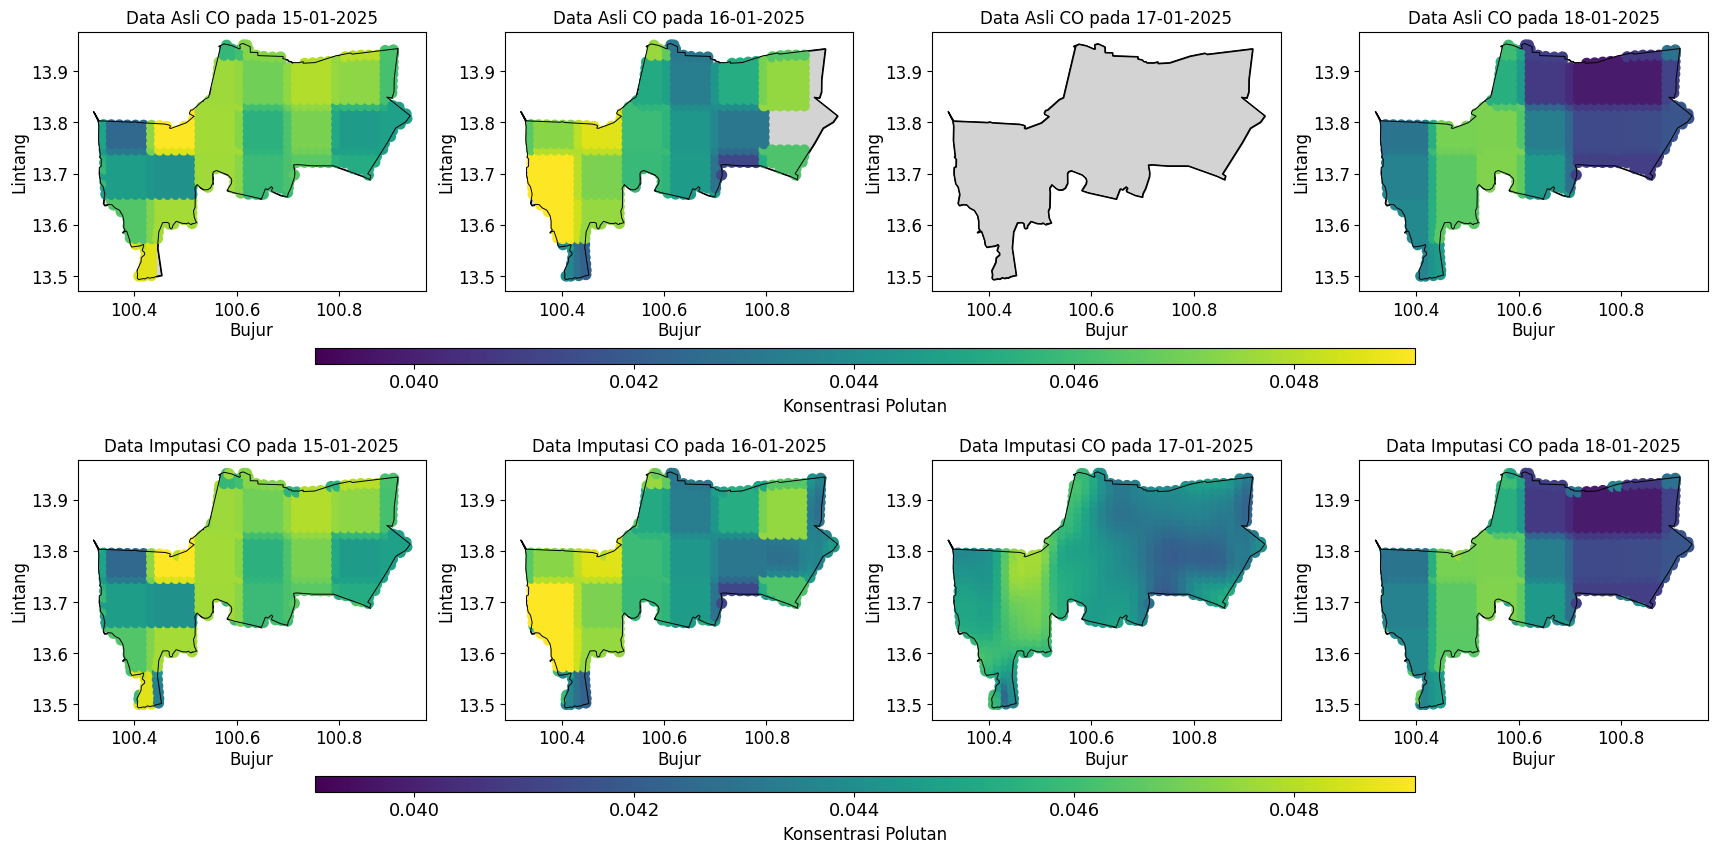

In [ ]:
# @title
# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(5.5 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Data Asli"), (df_imputation, "Data Imputasi")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")

        bangkok.plot(ax=ax, color='lightgray', edgecolor='black')
        bangkok.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
               cmap='viridis',
              vmin=vmin, vmax=vmax, markersize=50

            )
            mappables[label] = mappable


        ax.set_title(f"{label} CO pada {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Bujur", fontsize=12, labelpad=2)
        ax.set_ylabel("Lintang", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Konsentrasi Polutan", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Konsentrasi Polutan", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


/tmp/ipython-input-741741044.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-741741044.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-741741044.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-

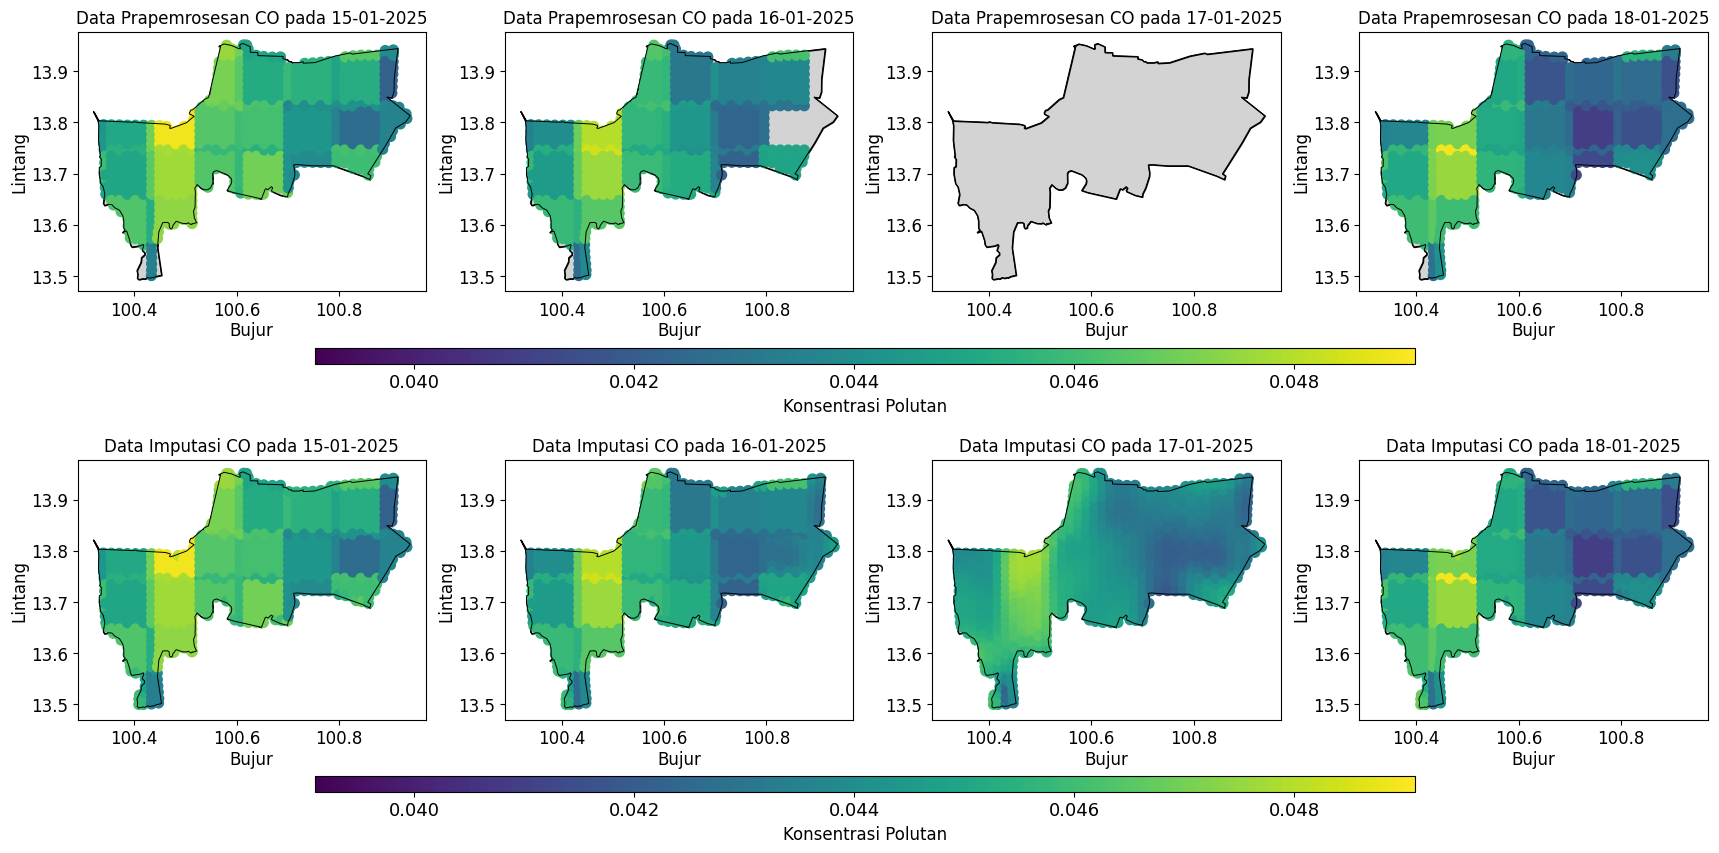

In [32]:
# @title
# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(5.5 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df_filter, "Data Prapemrosesan"), (df_filtered_imputation, "Data Imputasi")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
           df_visualize = df[df['time'] == time_to_visualize].copy()
           df_visualize = df_visualize.rename(columns={'CO_mean':'CO_filtered'})

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")

        bangkok.plot(ax=ax, color='lightgray', edgecolor='black')
        bangkok.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_filtered', ax=ax,
               cmap='viridis',
              vmin=vmin, vmax=vmax, markersize=50

            )
            mappables[label] = mappable


        ax.set_title(f"{label} CO pada {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Bujur", fontsize=12, labelpad=2)
        ax.set_ylabel("Lintang", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Konsentrasi Polutan", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Konsentrasi Polutan", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


/tmp/ipython-input-3518516449.py:27: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-3518516449.py:27: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-3518516449.py:27: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-inp

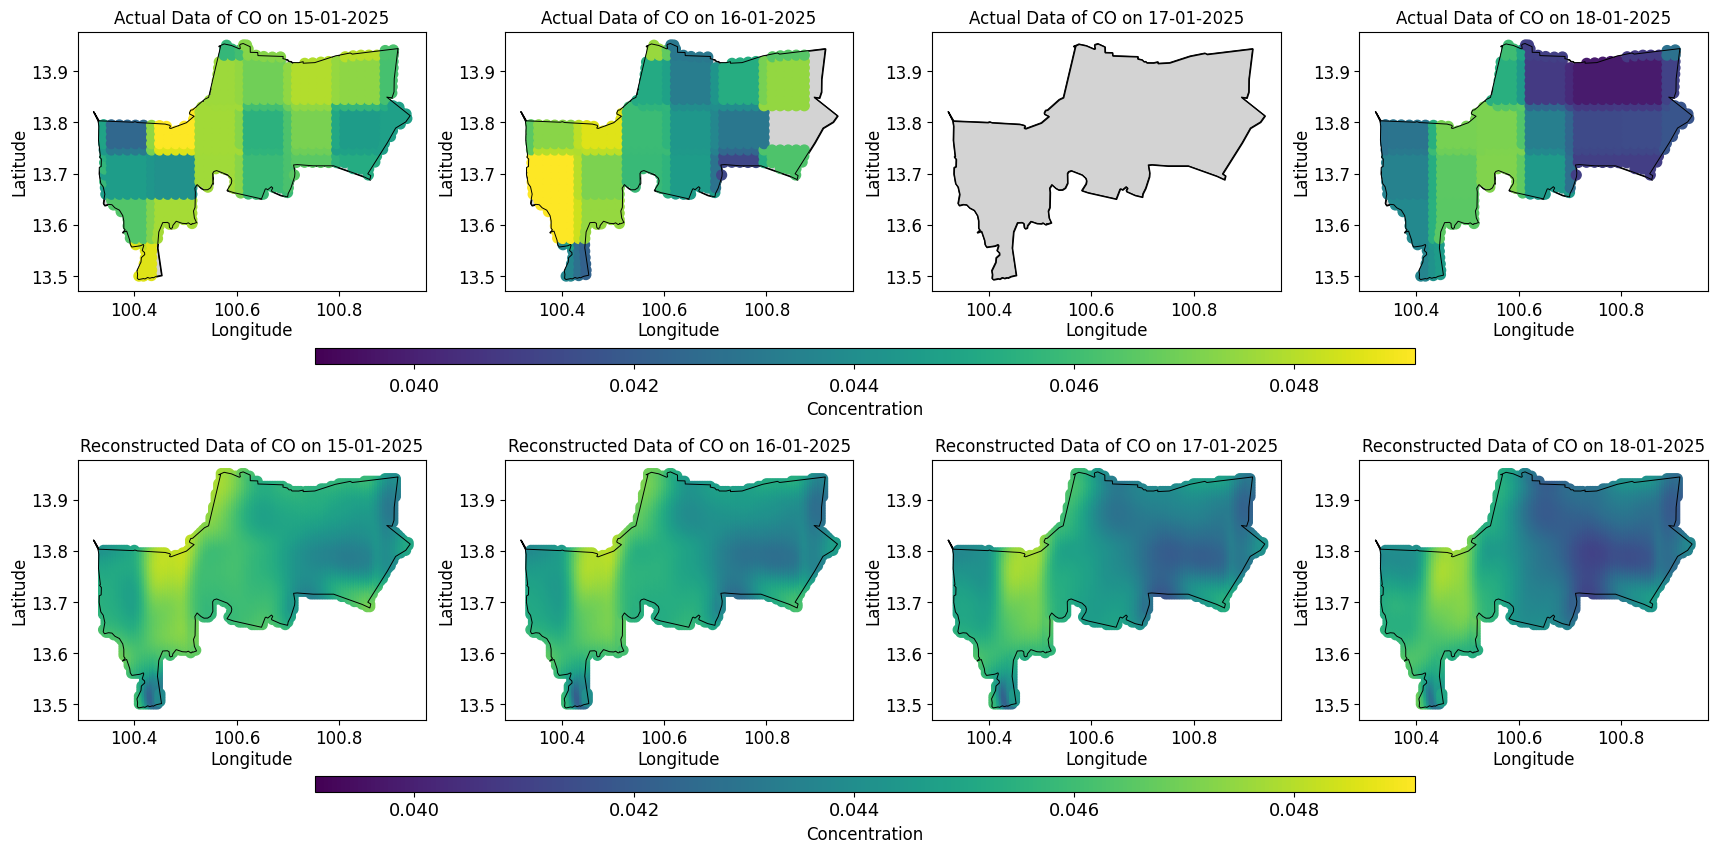

In [ ]:
# @title


predict = prediction_df.copy()
predict = predict.rename(columns={'prediction':'CO_mean','t':'time','x':'x_coord','y':'y_coord'})


# --- Step 5: Setup figure (rows = dates, cols = 2 for df & df_imputation) ---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(5.5 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Actual Data"), (predict, "Reconstructed Data")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")

        bangkok.plot(ax=ax, color='lightgray', edgecolor='black')
        bangkok.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                cmap='viridis',
                vmin=vmin, vmax=vmax, markersize=50
            )
            mappables[label] = mappable

        ax.set_title(f"{label} of CO on {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Longitude", fontsize=12, labelpad=2)
        ax.set_ylabel("Latitude", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Concentration", fontsize=12)
cbar1.ax.tick_params(labelsize=13,pad=6)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Concentration", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


/tmp/ipython-input-1726967738.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-1726967738.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-1726967738.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-inp

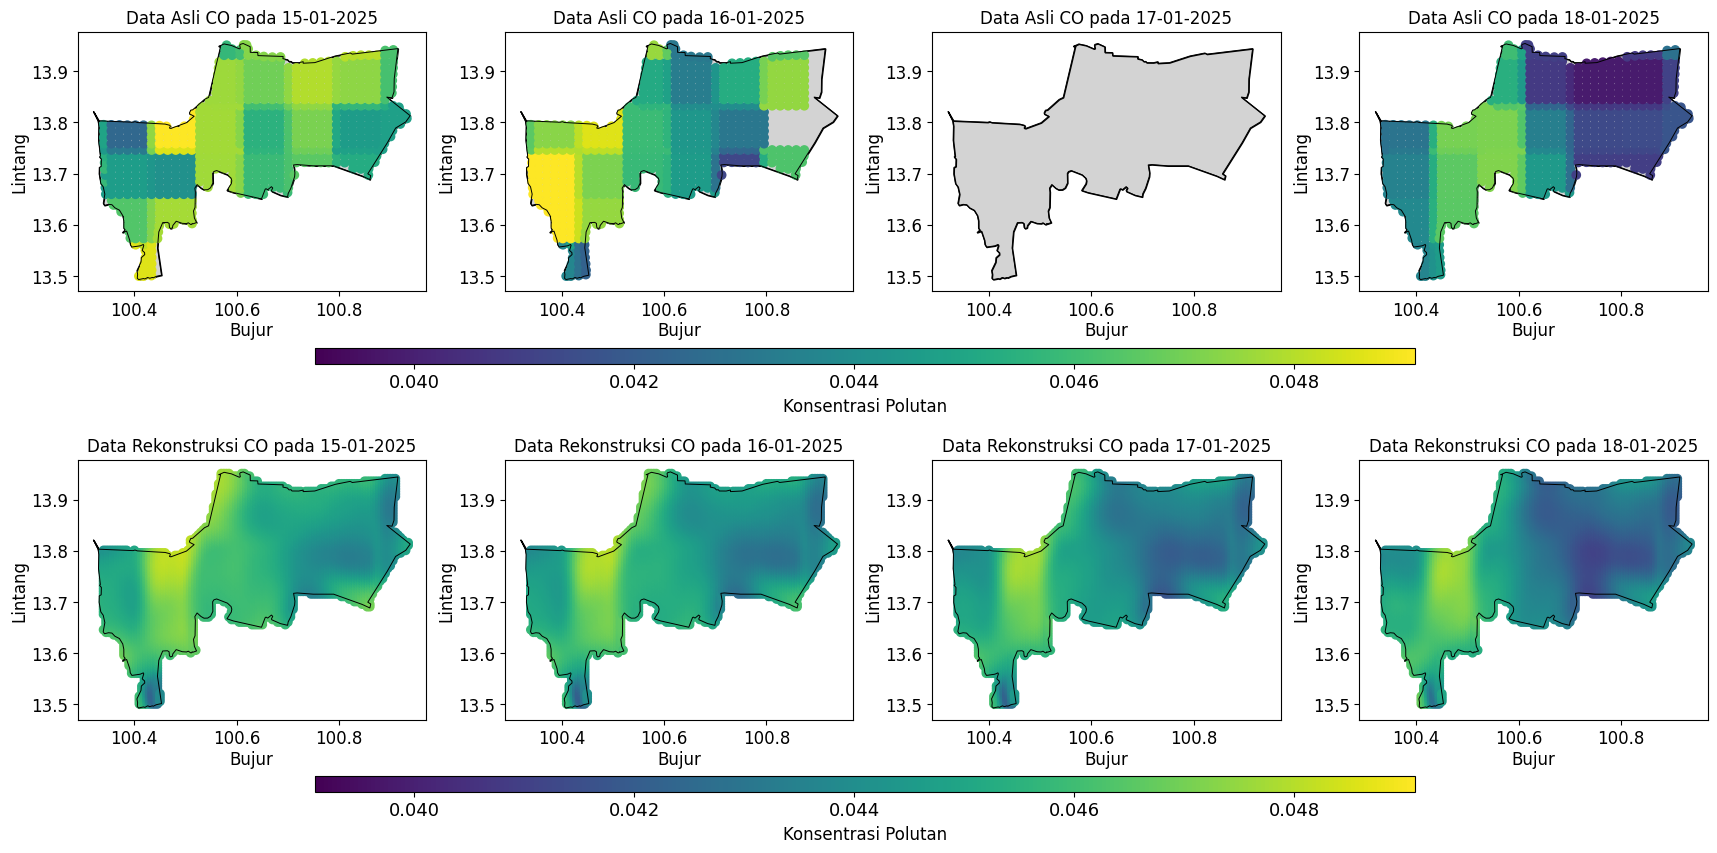

In [ ]:
# @title
# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(5.5 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Data Asli"), (predict, "Data Rekonstruksi")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")

        bangkok.plot(ax=ax, color='lightgray', edgecolor='black')
        bangkok.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='CO_mean', ax=ax,
                cmap='viridis', vmin=vmin, vmax=vmax
            )
            mappables[label] = mappable


        ax.set_title(f"{label} CO pada {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Bujur", fontsize=12, labelpad=2)
        ax.set_ylabel("Lintang", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Konsentrasi Polutan", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Konsentrasi Polutan", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()
